# 05 — Análisis del Parque Vehicular Liviano y PM2.5 · Ciudad de Guatemala 2022-2025

## Fase 1: Entendimiento del Negocio / Investigación

**Tesis:** *Análisis del efecto del aumento del parque vehicular liviano y el deterioro de la calidad del aire con PM2.5 en la Ciudad Capital, Guatemala 2022-2025.*

### Contexto y justificación
Las partículas finas (PM2.5, diámetro aerodinámico < 2.5 µm) constituyen uno de los contaminantes atmosféricos con mayor impacto documentado en la salud pública. En ciudades latinoamericanas con alta densidad vehicular y flota antigua, el tráfico rodado es la principal fuente de emisión de PM2.5. Guatemala City ha experimentado un crecimiento sostenido de su parque vehicular liviano (automóviles, pick-ups, motocicletas, SUVs), lo que plantea la hipótesis central de esta investigación.

### Objetivos analíticos
1. Describir la evolución temporal del parque vehicular liviano y los niveles de PM2.5 durante el período 2022-2025.
2. Modelar la serie temporal de PM2.5 mediante ARIMA y SARIMAX, incorporando el volumen vehicular como variable exógena.
3. Cuantificar y contrastar correlaciones entre PM2.5 mensual y el parque vehicular segmentado por modelo, tipo y línea de vehículo.

### Marco metodológico
Se aplica **CRISP-DM** (Cross-Industry Standard Process for Data Mining) como marco rector del análisis, garantizando trazabilidad y reproducibilidad académica.

## Fase 2: Entendimiento de los Datos

### 2.1 Carga de librerías

In [310]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro, jarque_bera

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2.2 Carga de datos

In [311]:
PATH_VEH = 'Data/Vehiculos/PARQUE-VEHICULAR-2007-2025-FULL.csv'
PATH_PM  = 'Data/PM25/PM25_DAIRY_FULL_2022_2025.csv'

df_veh = pd.read_csv(PATH_VEH, low_memory=False)
df_pm  = pd.read_csv(PATH_PM)

print(f"Parque vehicular — filas: {len(df_veh):,}  |  columnas: {df_veh.shape[1]}")
print(f"PM2.5            — filas: {len(df_pm):,}  |  columnas: {df_pm.shape[1]}")

Parque vehicular — filas: 499,773  |  columnas: 8
PM2.5            — filas: 1,380  |  columnas: 4


### 2.3 Exploración inicial — Parque Vehicular

In [312]:
display(df_veh.head(3))
print("\nTipos de datos:")
display(df_veh.dtypes.to_frame('dtype'))
print("\nValores nulos:")
display(df_veh.isnull().sum().to_frame('nulos'))
print("\nEstadísticas descriptivas (CANTIDAD):")
display(df_veh['CANTIDAD'].describe().to_frame())

,ANIO_ALZA,MES,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,USO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2007,5,2003,SANTA FE V6 4X2,CAMIONETA,PARTICULAR,HYUNDAI,1
1,2007,5,2001,SWIFT,AUTOMOVIL,PARTICULAR,SUZUKI,1
2,2007,5,1995,METRO LSI,AUTOMOVIL,PARTICULAR,GEO,1



Tipos de datos:


,dtype
ANIO_ALZA,int64
MES,int64
MODELO_VEHICULO,str
LINEA_VEHICULO,str
TIPO_VEHICULO,str
USO_VEHICULO,str
MARCA_VEHICULO,str
CANTIDAD,int64



Valores nulos:


,nulos
ANIO_ALZA,0
MES,0
MODELO_VEHICULO,0
LINEA_VEHICULO,0
TIPO_VEHICULO,0
USO_VEHICULO,0
MARCA_VEHICULO,0
CANTIDAD,0



Estadísticas descriptivas (CANTIDAD):


,CANTIDAD
count,"499,773.0000"
mean,2.8593
std,15.1095
min,1.0000
25%,1.0000
50%,1.0000
75%,2.0000
max,"1,889.0000"


### 2.4 Exploración inicial — PM2.5

In [313]:
display(df_pm.head(3))
print("\nTipos de datos:")
display(df_pm.dtypes.to_frame('dtype'))
print("\nValores nulos:")
display(df_pm.isnull().sum().to_frame('nulos'))
print("\nEstadísticas descriptivas PM2.5 (μg/m³):")
display(df_pm['PM25'].describe().to_frame())

,YEAR,MONTH,DAY,PM25
0,2022,3,4,4.6000
1,2022,3,7,42.0000
2,2022,3,8,55.0000



Tipos de datos:


,dtype
YEAR,int64
MONTH,int64
DAY,int64
PM25,float64



Valores nulos:


,nulos
YEAR,0
MONTH,0
DAY,0
PM25,0



Estadísticas descriptivas PM2.5 (μg/m³):


,PM25
count,"1,380.0000"
mean,30.4328
std,42.2411
min,0.8000
25%,9.1000
50%,18.1500
75%,37.1250
max,"1,016.0000"


### 2.5 Distribución global de PM2.5 (serie diaria completa)

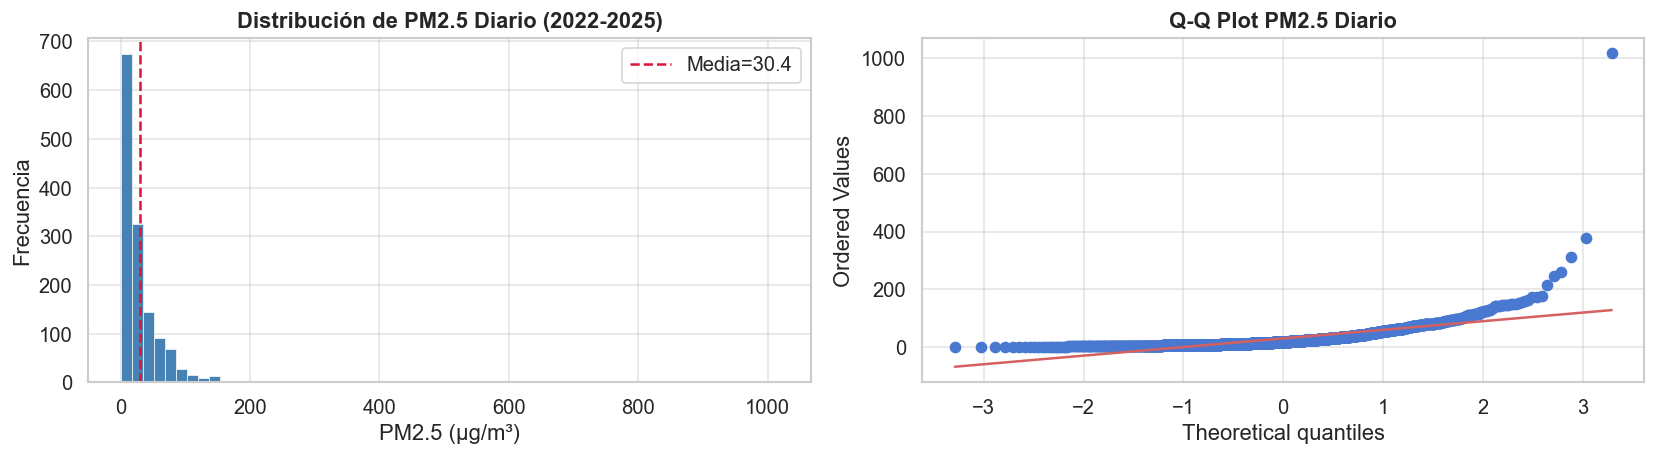

Rango temporal: 2022-03 → 2025-12


In [314]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_pm['PM25'].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribución de PM2.5 Diario (2022-2025)', fontweight='bold')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_pm['PM25'].mean(), color='crimson', linestyle='--', label=f'Media={df_pm["PM25"].mean():.1f}')
axes[0].legend()

stats.probplot(df_pm['PM25'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot PM2.5 Diario', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rango temporal: {df_pm['YEAR'].min()}-{int(df_pm['MONTH'][df_pm['YEAR']==df_pm['YEAR'].min()].min()):02d} "
      f"→ {df_pm['YEAR'].max()}-{int(df_pm['MONTH'][df_pm['YEAR']==df_pm['YEAR'].max()].max()):02d}")

## Fase 3: Preparación de los Datos

### 3.1 PM2.5 — Media mensual (Marzo 2022 – Diciembre 2025)

Se construye una columna `DATE` tipo datetime, se filtra el período de estudio y se remuestrea agrupando por año-mes para obtener la **media mensual** de PM2.5.

In [315]:
df_pm['DATE'] = pd.to_datetime(dict(year=df_pm['YEAR'], month=df_pm['MONTH'], day=df_pm['DAY']))
df_pm_f = df_pm[(df_pm['DATE'] >= '2022-03-01') & (df_pm['DATE'] <= '2025-12-31')].copy()

pm_mensual = (df_pm_f.groupby(['YEAR','MONTH'])['PM25']
              .mean()
              .reset_index()
              .rename(columns={'PM25':'PM25_MEAN'}))

pm_mensual['PERIOD'] = pd.to_datetime(
    pm_mensual['YEAR'].astype(str) + '-' + pm_mensual['MONTH'].astype(str).str.zfill(2))
pm_mensual = pm_mensual.sort_values('PERIOD').reset_index(drop=True)

print(f"Registros mensuales PM2.5: {len(pm_mensual)}")
display(pm_mensual.head(6))

Registros mensuales PM2.5: 46


,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,3,36.2192,2022-03-01
1,2022,4,34.6538,2022-04-01
2,2022,5,35.0429,2022-05-01
3,2022,6,18.1700,2022-06-01
4,2022,7,11.1000,2022-07-01
5,2022,8,21.2333,2022-08-01


In [316]:
mean_jan = pm_mensual[pm_mensual['MONTH'] == 1]['PM25_MEAN'].mean()
mean_feb = pm_mensual[pm_mensual['MONTH'] == 2]['PM25_MEAN'].mean()

print(mean_jan)
print(mean_feb)

# 2. Crear un DataFrame con los meses a predecir
predicciones_2022 = pd.DataFrame({
    'YEAR': [2022, 2022],
    'MONTH': [1, 2],
    'PM25_MEAN': [mean_jan, mean_feb],
    'PERIOD': pd.to_datetime(['2022-01-01', '2022-02-01'])
})

# 3. Unir las predicciones con el dataset original y reordenar
pm_mensual = pd.concat([predicciones_2022, pm_mensual], ignore_index=True)
pm_mensual = pm_mensual.sort_values('PERIOD').reset_index(drop=True)

print(f"Registros mensuales PM2.5 actualizados: {len(pm_mensual)}")
display(pm_mensual.head(6))

30.279641577060932
25.75646422820336
Registros mensuales PM2.5 actualizados: 48


,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,1,30.2796,2022-01-01
1,2022,2,25.7565,2022-02-01
2,2022,3,36.2192,2022-03-01
3,2022,4,34.6538,2022-04-01
4,2022,5,35.0429,2022-05-01
5,2022,6,18.1700,2022-06-01


### 3.2 Parque Vehicular — Altas mensuales (Enero 2022 – Diciembre 2025)

Se filtran únicamente los registros cuyo año/mes de alta (`ANIO_ALZA`, `MES`) caen dentro del período de estudio. Se suma `CANTIDAD` para obtener el total de vehículos que ingresaron a circulación cada mes.

In [317]:
df_veh['ANIO_ALZA'] = pd.to_numeric(df_veh['ANIO_ALZA'], errors='coerce')
df_veh['MES']       = pd.to_numeric(df_veh['MES'],       errors='coerce')
df_veh.dropna(subset=['ANIO_ALZA','MES'], inplace=True)
df_veh['ANIO_ALZA'] = df_veh['ANIO_ALZA'].astype(int)
df_veh['MES']       = df_veh['MES'].astype(int)

df_veh['PERIOD_ALTA'] = pd.to_datetime(
    df_veh['ANIO_ALZA'].astype(str) + '-' + df_veh['MES'].astype(str).str.zfill(2))

mask = (df_veh['PERIOD_ALTA'] >= '2022-01-01') & (df_veh['PERIOD_ALTA'] <= '2025-12-31')
df_altas = df_veh[mask].copy()

mask2 = (df_veh['PERIOD_ALTA'] >= '1980-01-01') & (df_veh['PERIOD_ALTA'] <= '2025-12-31')
df_acum = df_veh[mask2].copy()

altas_mensual = (df_altas.groupby('PERIOD_ALTA')['CANTIDAD']
                 .sum()
                 .reset_index()
                 .rename(columns={'PERIOD_ALTA':'PERIOD', 'CANTIDAD':'ALTAS_MENS'}))
altas_mensual = altas_mensual.sort_values('PERIOD').reset_index(drop=True)

print(f"Meses con altas en período de estudio: {len(altas_mensual)}")
print(f"Total vehículos ingresados 2022-2025: {altas_mensual['ALTAS_MENS'].sum():,}")
display(altas_mensual.head(6))

Meses con altas en período de estudio: 48
Total vehículos ingresados 2022-2025: 487,592


,PERIOD,ALTAS_MENS
0,2022-01-01,8823
1,2022-02-01,8520
2,2022-03-01,9019
3,2022-04-01,8897
4,2022-05-01,9418
5,2022-06-01,10737


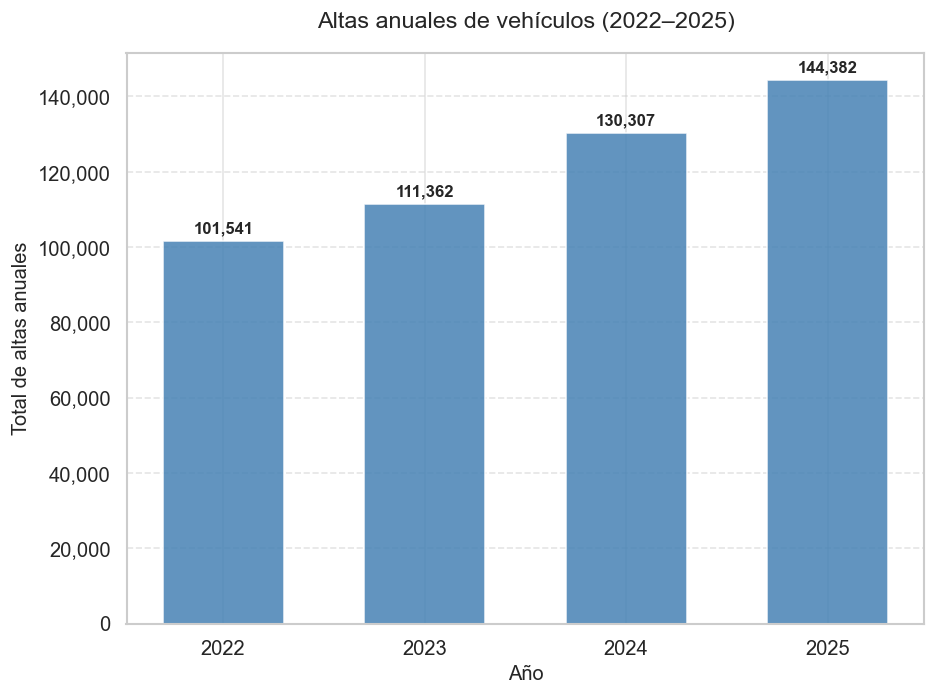

In [318]:
# 1. Asegurar que 'PERIOD' sea de tipo datetime (si no lo es ya)
altas_mensual['PERIOD'] = pd.to_datetime(altas_mensual['PERIOD'])

# 2. Agrupar los datos por año sumando la cantidad de vehículos
#    (Usamos la columna 'ALTAS_MENS' para consolidar el total del año)
altas_anual = altas_mensual.groupby(altas_mensual['PERIOD'].dt.year)['ALTAS_MENS'].sum().reset_index()
altas_anual.columns = ['ANIO', 'TOTAL_ANUAL']

# 3. Graficar
plt.figure(figsize=(8, 6))
bars = plt.bar(altas_anual['ANIO'].astype(str), altas_anual['TOTAL_ANUAL'],
               color='steelblue', alpha=0.85, width=0.6)

plt.title('Altas anuales de vehículos (2022–2025)', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de altas anuales', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Formatear el eje Y con comas para los miles
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Añadir etiquetas de datos arriba de cada barra para que sea ultra legible
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 puntos de desfase vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

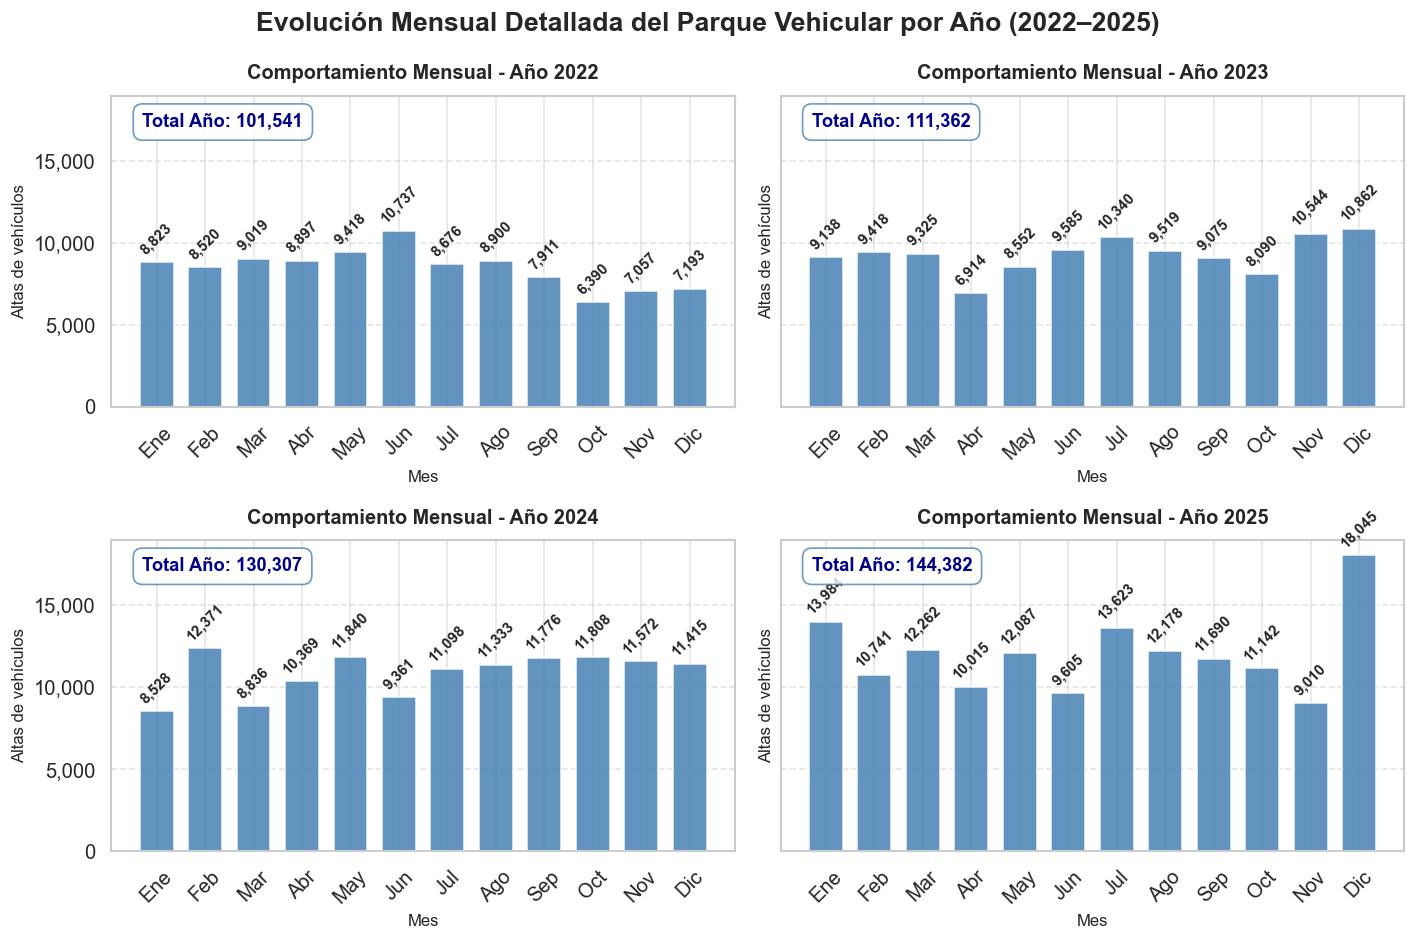

In [319]:
# 1. Asegurar formato de fecha y extraer Año y Mes
altas_mensual['PERIOD'] = pd.to_datetime(altas_mensual['PERIOD'])
altas_mensual['ANIO'] = altas_mensual['PERIOD'].dt.year
altas_mensual['MES'] = altas_mensual['PERIOD'].dt.month

# Lista de años únicos a graficar
anios = sorted(altas_mensual['ANIO'].unique())

# 2. Configurar la matriz de gráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.flatten()

# Lista de nombres de meses abreviados para el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# 3. Iterar sobre cada año y dibujar su respectiva gráfica de barras mensual
for i, anio in enumerate(anios):
    ax = axes[i]

    # Filtrar los datos para el año en curso
    datos_anio = altas_mensual[altas_mensual['ANIO'] == anio].sort_values('MES')

    # Calcular el total del año para mostrarlo en la gráfica
    total_del_anio = datos_anio['ALTAS_MENS'].sum()

    # Dibujamos las barras y guardamos el objeto en la variable 'barras'
    barras = ax.bar(datos_anio['MES'], datos_anio['ALTAS_MENS'],
                    color='steelblue', alpha=0.85, width=0.7, label=f'Altas {anio}')

    # --- NUEVO: Etiquetas con el valor encima de cada barra ---
    # padding=3 separa el texto un poco de la barra; fmt realiza el formato con comas
    ax.bar_label(barras, padding=3, fmt='{:,.0f}', fontsize=9, weight='bold', rotation=45)

    # Agregar el recuadro con el total anual
    ax.text(0.05, 0.90, f'Total Año: {total_del_anio:,.0f}',
            transform=ax.transAxes, fontsize=11, weight='bold', color='darkblue',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='steelblue', boxstyle='round,pad=0.5'))

    # Títulos y etiquetas de cada cuadrante
    ax.set_title(f'Comportamiento Mensual - Año {anio}', fontsize=12, weight='bold', pad=10)
    ax.set_xlabel('Mes', fontsize=10)
    ax.set_ylabel('Altas de vehículos', fontsize=10)

    # Forzar a que el eje X muestre los 12 meses
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nombres_meses, rotation=45)

    # Formatear el eje Y con separadores de miles
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Ajustes estéticos globales
plt.suptitle('Evolución Mensual Detallada del Parque Vehicular por Año (2022–2025)',
             fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 3.3 Parque Vehicular — Inventario ACUMULADO circulante

El parque circulante real en cada mes es el acumulado histórico de todos los vehículos que han ingresado hasta ese período. Se calcula con un `cumsum()` sobre las altas mensuales dentro del período de estudio.

In [320]:
altas_mensual_acum = (df_acum.groupby('PERIOD_ALTA')['CANTIDAD']
                 .sum()
                 .reset_index()
                 .rename(columns={'PERIOD_ALTA':'PERIOD', 'CANTIDAD':'ALTAS_MENS'}))

altas_mensual_acum = altas_mensual_acum.sort_values('PERIOD').reset_index(drop=True)
altas_mensual_acum['ACUMULADO'] = altas_mensual_acum['ALTAS_MENS'].cumsum()
print("Parque vehicular acumulado al final del período:")
print(f"  {altas_mensual_acum['ACUMULADO'].iloc[-1]:,} vehículos")
display(altas_mensual_acum.tail(6))

Parque vehicular acumulado al final del período:
  1,428,999 vehículos


,PERIOD,ALTAS_MENS,ACUMULADO
423,2025-07-01,13623,1366934
424,2025-08-01,12178,1379112
425,2025-09-01,11690,1390802
426,2025-10-01,11142,1401944
427,2025-11-01,9010,1410954
428,2025-12-01,18045,1428999


In [321]:
pm_mensual.head(3)

,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,1,30.2796,2022-01-01
1,2022,2,25.7565,2022-02-01
2,2022,3,36.2192,2022-03-01


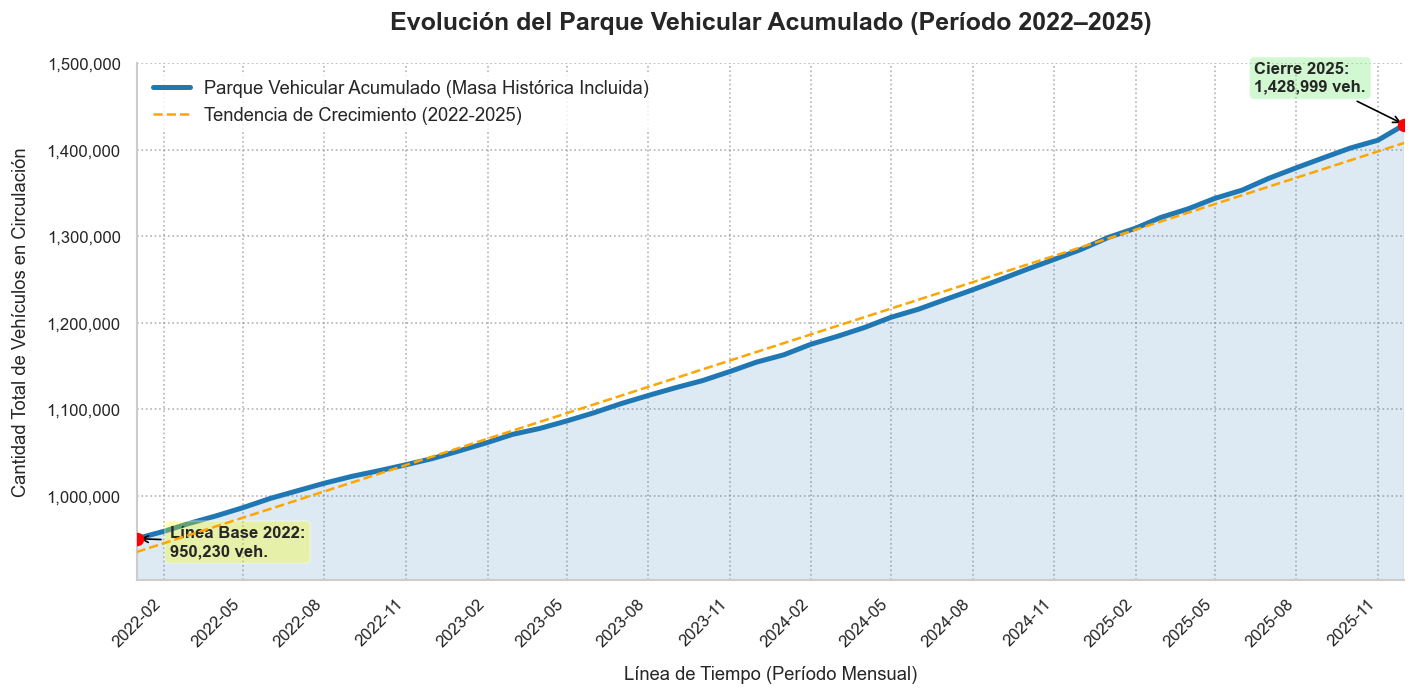

In [322]:
# 1. Asegurar formato de fecha
altas_mensual_acum['PERIOD'] = pd.to_datetime(altas_mensual_acum['PERIOD'])

# --- LOGICA CORREGIDA ---
# Primero: Ordenamos cronológicamente y calculamos el acumulado HISTÓRICO TOTAL
altas_mensual_acum = altas_mensual_acum.sort_values('PERIOD').reset_index(drop=True)
altas_mensual_acum['ACUMULADO'] = altas_mensual_acum['ALTAS_MENS'].cumsum()

# Segundo: AHORA SÍ filtramos el dataset para quedarnos ÚNICAMENTE con el período visual de la tesis
df_grafico = altas_mensual_acum[
    (altas_mensual_acum['PERIOD'] >= '2022-01-01') &
    (altas_mensual_acum['PERIOD'] <= '2025-12-31')
].copy()
# ------------------------

# 2. Configuración de la figura
plt.figure(figsize=(12, 6), facecolor='white')
ax = plt.gca()

# 3. Graficar la curva principal utilizando el DataFrame filtrado (pero con la masa histórica calculada)
plt.plot(df_grafico['PERIOD'], df_grafico['ACUMULADO'],
         color='#1f77b4', linewidth=3, label='Parque Vehicular Acumulado (Masa Histórica Incluida)', zorder=3)

plt.fill_between(df_grafico['PERIOD'], df_grafico['ACUMULADO'],
                 color='#1f77b4', alpha=0.15, zorder=2)

# 4. Línea de tendencia promedio basada en el comportamiento 2022–2025
y = df_grafico['ACUMULADO']
m, b = np.polyfit(mdates.date2num(df_grafico['PERIOD']), y, 1)
plt.plot(df_grafico['PERIOD'], m * mdates.date2num(df_grafico['PERIOD']) + b,
         color='orange', linestyle='--', linewidth=1.5, label='Tendencia de Crecimiento (2022-2025)', zorder=4)

# 5. ANOTACIONES: Extremos reales del período de la tesis
# Punto Inicial (Enero 2022 - Mostrará el acumulado heredado de años anteriores)
p_inicio_x = df_grafico['PERIOD'].iloc[0]
p_inicio_y = df_grafico['ACUMULADO'].iloc[0]
plt.scatter(p_inicio_x, p_inicio_y, color='red', s=50, zorder=5)
ax.annotate(f'Línea Base 2022:\n{p_inicio_y:,.0f} veh.',
            xy=(p_inicio_x, p_inicio_y), xytext=(20, -10),
            textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, weight='bold')

# Punto Final (Diciembre 2025)
p_final_x = df_grafico['PERIOD'].iloc[-1]
p_final_y = df_grafico['ACUMULADO'].iloc[-1]
plt.scatter(p_final_x, p_final_y, color='red', s=50, zorder=5)
ax.annotate(f'Cierre 2025:\n{p_final_y:,.0f} veh.',
            xy=(p_final_x, p_final_y), xytext=(-90, 20),
            textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.4),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, weight='bold')

# Forzar los límites visuales exactos del eje X para que empiece en 2022 y cierre en 2025
ax.set_xlim(df_grafico['PERIOD'].min(), df_grafico['PERIOD'].max())

# Ajustar el límite inferior de Y para que la gráfica no empiece desde 0 de forma innecesaria,
# permitiendo apreciar mejor la pendiente de crecimiento a partir del volumen heredado.
ax.set_ylim(df_grafico['ACUMULADO'].min() * 0.95, df_grafico['ACUMULADO'].max() * 1.05)

# 6. Formateo estricto de los Ejes
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right', fontsize=10)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.yticks(fontsize=10)

# 7. Títulos, Leyendas y Limpieza Visual
plt.title('Evolución del Parque Vehicular Acumulado (Período 2022–2025)', fontsize=15, weight='bold', pad=20)
plt.xlabel('Línea de Tiempo (Período Mensual)', fontsize=11, labelpad=10)
plt.ylabel('Cantidad Total de Vehículos en Circulación', fontsize=11, labelpad=10)

plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 3.4 Dataset consolidado (merge por período mensual)

In [323]:
pm_mensual.head(50)

,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,1,30.2796,2022-01-01
1,2022,2,25.7565,2022-02-01
2,2022,3,36.2192,2022-03-01
3,2022,4,34.6538,2022-04-01
4,2022,5,35.0429,2022-05-01
5,2022,6,18.1700,2022-06-01
6,2022,7,11.1000,2022-07-01
7,2022,8,21.2333,2022-08-01
8,2022,9,29.6500,2022-09-01
9,2022,10,26.2871,2022-10-01


In [324]:


df_merged = pd.merge(pm_mensual[['PERIOD','PM25_MEAN']],
                     altas_mensual_acum[['PERIOD','ALTAS_MENS','ACUMULADO']],
                     on='PERIOD', how='inner')
df_merged = df_merged.sort_values('PERIOD').reset_index(drop=True)
#df_merged.index = df_merged['PERIOD']

print(f"Dataset consolidado — {len(df_merged)} períodos mensuales")
print(f"Rango: {df_merged['PERIOD'].min().strftime('%Y-%m')} → {df_merged['PERIOD'].max().strftime('%Y-%m')}")
display(df_merged.head(3))

Dataset consolidado — 48 períodos mensuales
Rango: 2022-01 → 2025-12


,PERIOD,PM25_MEAN,ALTAS_MENS,ACUMULADO
0,2022-01-01,30.2796,8823,950230
1,2022-02-01,25.7565,8520,958750
2,2022-03-01,36.2192,9019,967769


### 3.5 Visualización de las series temporales consolidadas

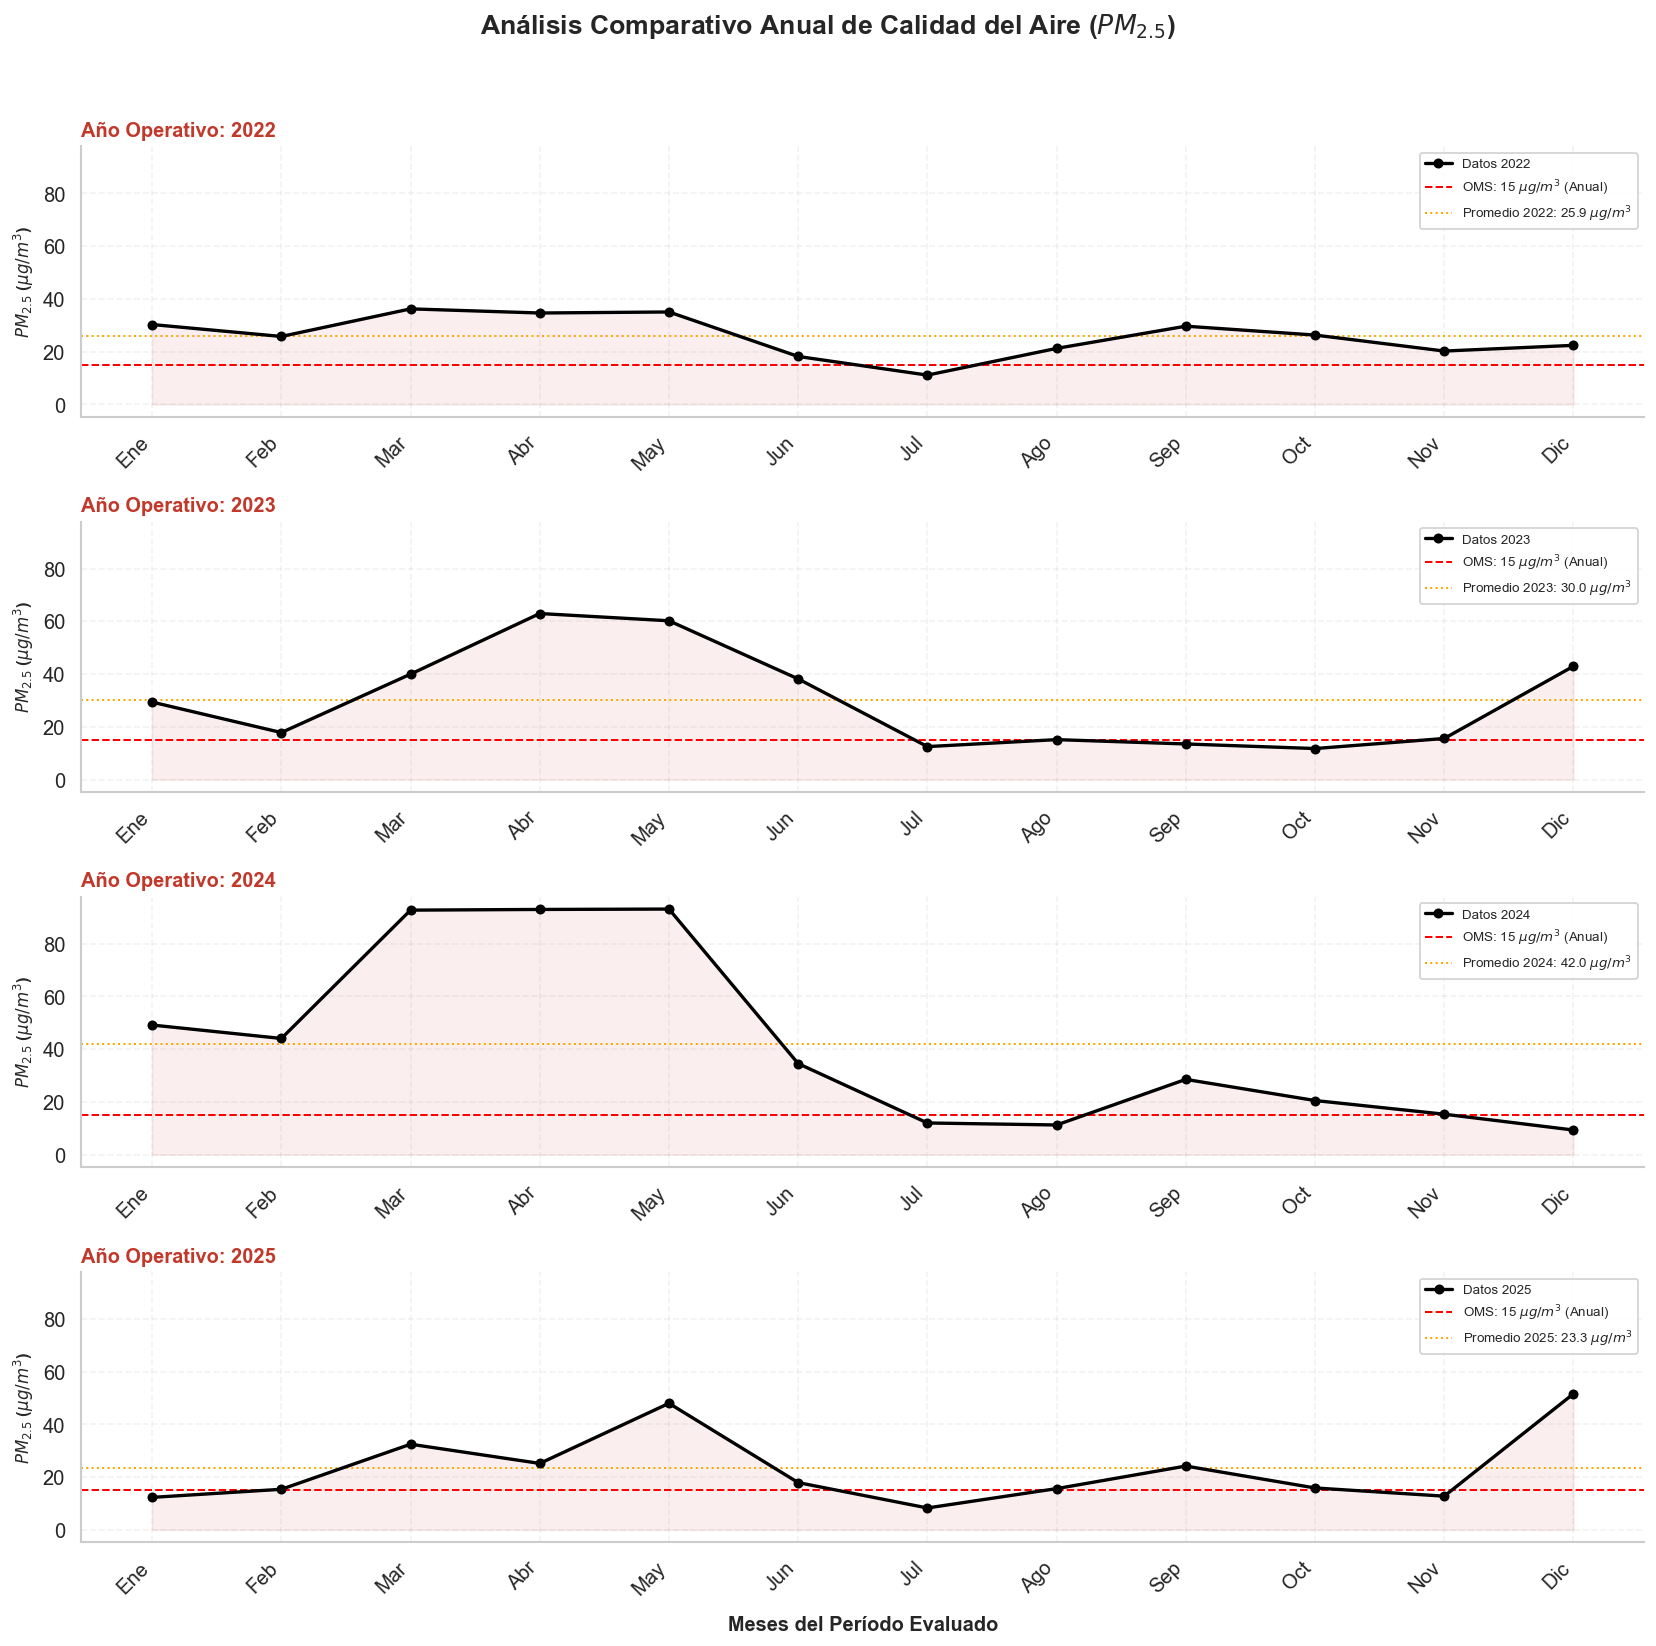

In [325]:
# 1. Asegurar la extracción de componentes temporales
df_merged['PERIOD'] = pd.to_datetime(df_merged['PERIOD'])
df_merged['ANIO'] = df_merged['PERIOD'].dt.year
df_merged['MES_NUM'] = df_merged['PERIOD'].dt.month

# Lista de años de estudio
anios = [2022, 2023, 2024, 2025]
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# 2. Crear la figura con 4 paneles verticales (uno para cada año)
# sharey=True es CRUCIAL para que la terna pueda comparar magnitudes visualmente sin engaños de escala
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True, sharey=True)
fig.suptitle('Análisis Comparativo Anual de Calidad del Aire ($PM_{2.5}$)',
             fontsize=16, fontweight='bold', y=0.98)

# Calcular el promedio histórico global para tenerlo como referencia estática en todos los paneles
prom_global = df_merged['PM25_MEAN'].mean()

# 3. Iterar sobre cada año para construir su respectivo panel
for i, anio in enumerate(anios):
    ax = axes[i]

    # Filtrar datos exclusivamente de ese año ordenados por mes
    df_anio = df_merged[df_merged['ANIO'] == anio].sort_values('MES_NUM')

    # Graficar la curva del año actual
    ax.plot(df_anio['MES_NUM'], df_anio['PM25_MEAN'],
            color='#000000', marker='o', markersize=5, linewidth=2, zorder=3, label=f'Datos {anio}')
    ax.fill_between(df_anio['MES_NUM'], df_anio['PM25_MEAN'],
                    color='#c0392b', alpha=0.08, zorder=1)

    # Líneas de referencia normativas (Guías OMS)
    ax.axhline(15, color='red', linestyle='--', linewidth=1.2, label='OMS: 15 $\mu g/m^3$ (Anual)')
    #ax.axhline(25, color='red', linestyle='--', linewidth=1.2, label='OMS: 25 $\mu g/m^3$ (24 h)')

    # Línea del promedio específico de ESE año (Información analítica extra)
    prom_anio = df_anio['PM25_MEAN'].mean()
    ax.axhline(prom_anio, color='#FFA500', linestyle=':', linewidth=1.2,
               label=f'Promedio {anio}: {prom_anio:.1f} $\mu g/m^3$')

    # Formateo de etiquetas y títulos por panel
    ax.set_ylabel('$PM_{2.5}$ ($\mu g/m^3$)', fontsize=10, fontweight='bold')
    ax.set_title(f'Año Operativo: {anio}', fontsize=12, fontweight='bold', loc='left', color='#c0392b')

    # Ubicación limpia de la leyenda
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9, edgecolor='#cccccc')
    ax.grid(True, alpha=0.25, linestyle='--')

    # Configuración del eje X (Meses del año)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nombres_meses)
    ax.tick_params(axis='x', labelbottom=True, rotation=45)

    # Alinear las etiquetas de los meses hacia la derecha
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    # Limpieza visual de espinas estilizadas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ajuste fino final
plt.xlabel('Meses del Período Evaluado', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Output/pm25_comparativo_anual.png', dpi=150, bbox_inches='tight')
plt.show()

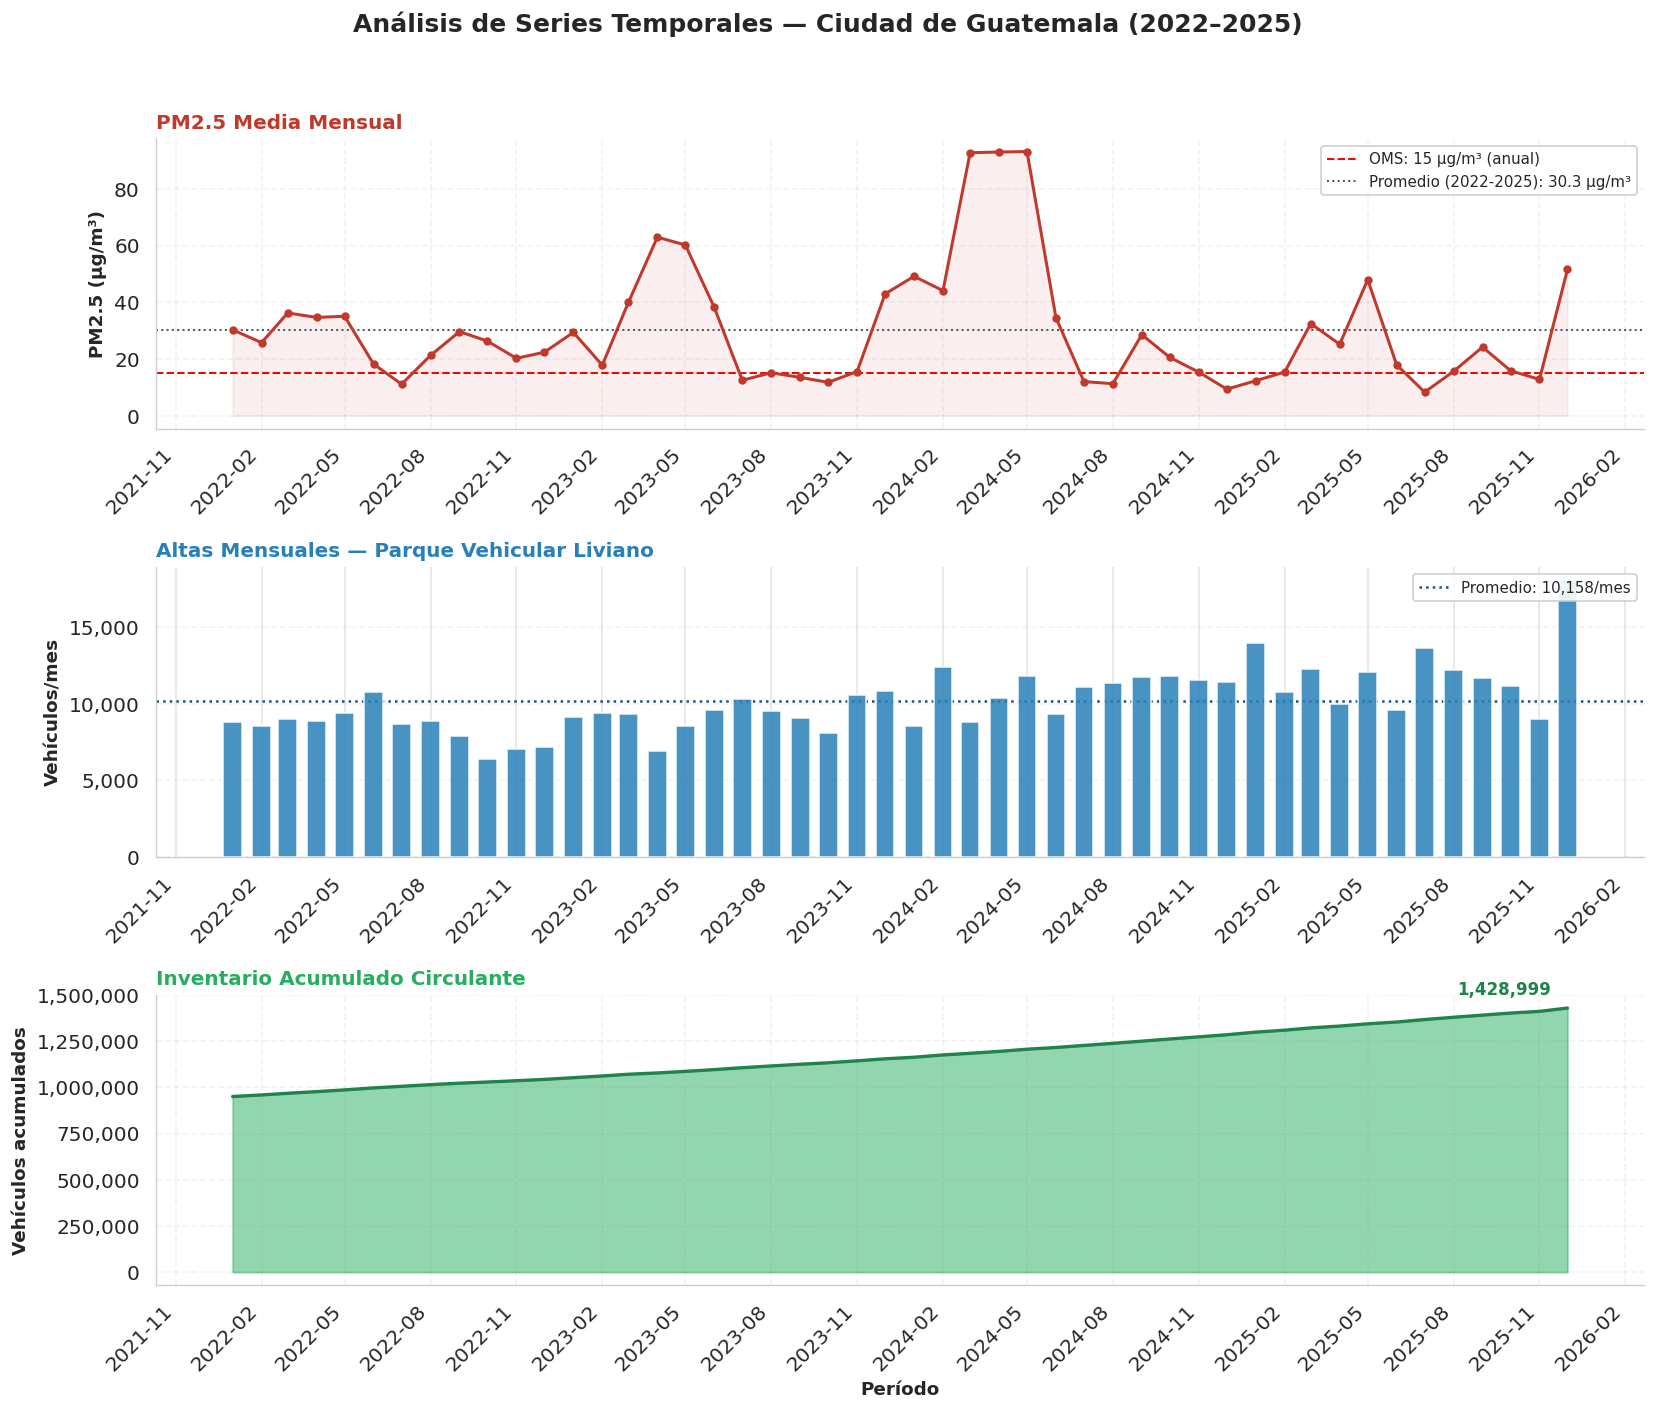

In [326]:

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True) # Se subió ligeramente la altura a 12 para dar espacio a las etiquetas rotadas
fig.suptitle('Análisis de Series Temporales — Ciudad de Guatemala (2022–2025)',
             fontsize=15, fontweight='bold', y=0.98)

# ---- Panel 1: PM2.5 ----
ax = axes[0]
ax.plot(df_merged['PERIOD'], df_merged['PM25_MEAN'],
        color='#c0392b', marker='o', markersize=4, linewidth=1.8, zorder=3)
ax.fill_between(df_merged['PERIOD'], df_merged['PM25_MEAN'],
                color='#c0392b', alpha=0.08, zorder=1)
ax.axhline(15, color='red', linestyle='--', linewidth=1.2, label='OMS: 15 μg/m³ (anual)')
#ax.axhline(25, color='red', linestyle='--', linewidth=1.2, label='OMS: 25 μg/m³ (24 h)')
prom = df_merged['PM25_MEAN'].mean()
ax.axhline(prom, color='#555555', linestyle=':', linewidth=1.2,
           label=f'Promedio (2022-2025): {prom:.1f} μg/m³')
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
ax.set_title('PM2.5 Media Mensual', fontsize=12, fontweight='bold', loc='left', color='#c0392b')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

# ---- Panel 2: Altas mensuales ----
ax = axes[1]
bars = ax.bar(df_merged['PERIOD'], df_merged['ALTAS_MENS'],
              color='#2980b9', alpha=0.85, width=20, zorder=3)
prom_altas = df_merged['ALTAS_MENS'].mean()
ax.axhline(prom_altas, color='#1a5276', linestyle=':', linewidth=1.5,
           label=f'Promedio: {prom_altas:,.0f}/mes')
ax.set_ylabel('Vehículos/mes', fontsize=11, fontweight='bold')
ax.set_title('Altas Mensuales — Parque Vehicular Liviano',
              fontsize=12, fontweight='bold', loc='left', color='#2980b9')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, axis='y', alpha=0.25, linestyle='--')

# ---- Panel 3: Acumulado ----
ax = axes[2]
ax.fill_between(df_merged['PERIOD'], df_merged['ACUMULADO'],
                alpha=0.5, color='#27ae60', zorder=1)
ax.plot(df_merged['PERIOD'], df_merged['ACUMULADO'],
        color='#1e8449', linewidth=2, zorder=3)
total = df_merged['ACUMULADO'].iloc[-1]
ax.annotate(f'{total:,.0f}',
            xy=(df_merged['PERIOD'].iloc[-1], total),
            xytext=(-10, 8), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#1e8449', ha='right')
ax.set_ylabel('Vehículos acumulados', fontsize=11, fontweight='bold')
ax.set_title('Inventario Acumulado Circulante',
              fontsize=12, fontweight='bold', loc='left', color='#27ae60')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Período', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.25, linestyle='--')


# ---- MODIFICACIÓN CRÍTICA: Configuración del Eje X en TODOS los paneles ----
for a in axes:
    # 1. Forzar a que las etiquetas inferiores sigan siendo visibles a pesar del sharex=True
    a.tick_params(axis='x', labelbottom=True, rotation=45)

    # 2. Asignar el intervalo de 3 meses a cada gráfica individual de forma explícita
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 3. Alinear el texto rotado a la derecha para que coincida exactamente con la marca (tick)
    for label in a.get_xticklabels():
        label.set_horizontalalignment('right')

    # 4. Limpieza estética de bordes
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)


# Ajuste fino final manteniendo las proporciones
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Output/series_temporales_consolidadas.png', dpi=150, bbox_inches='tight')
plt.show()

In [327]:

df_merged.to_csv('./Data/df_merged_limpio.csv', index=False, encoding='utf-8')


In [328]:
df_merged.head(6)

,PERIOD,PM25_MEAN,ALTAS_MENS,ACUMULADO,ANIO,MES_NUM
0,2022-01-01,30.2796,8823,950230,2022,1
1,2022-02-01,25.7565,8520,958750,2022,2
2,2022-03-01,36.2192,9019,967769,2022,3
3,2022-04-01,34.6538,8897,976666,2022,4
4,2022-05-01,35.0429,9418,986084,2022,5
5,2022-06-01,18.1700,10737,996821,2022,6


## Fase 4: Modelado de Series Temporales

### 4.1 Prueba de Estacionariedad — Test ADF (Augmented Dickey-Fuller)

Un modelo ARIMA requiere que la serie sea estacionaria (media y varianza constantes en el tiempo). El test ADF contrasta la hipótesis nula H₀: la serie tiene raíz unitaria (no estacionaria).

In [329]:
def adf_report(serie, nombre):
    result = adfuller(serie.dropna(), autolag='AIC')
    print(f"\n{'='*55}")
    print(f" ADF Test — {nombre}")
    print(f"{'='*55}")
    print(f"  Estadístico ADF : {result[0]:.4f}")
    print(f"  p-valor         : {result[1]:.4f}")
    print(f"  Lags utilizados : {result[2]}")
    print(f"  Obs. usadas     : {result[3]}")
    for k, v in result[4].items():
        print(f"  Valor crítico {k}: {v:.4f}")
    conclusion = "ESTACIONARIA " if result[1] < 0.05 else "NO ESTACIONARIA ✗ → diferenciación requerida"
    print(f"  Conclusión      : {conclusion}")
    return result[1]

p_pm25     = adf_report(df_merged['PM25_MEAN'],  'PM2.5 Media Mensual')
p_altas    = adf_report(df_merged['ALTAS_MENS'], 'Altas Mensuales')
p_acumul   = adf_report(df_merged['ACUMULADO'],  'Acumulado Circulante')


 ADF Test — PM2.5 Media Mensual
  Estadístico ADF : -3.5524
  p-valor         : 0.0067
  Lags utilizados : 1
  Obs. usadas     : 46
  Valor crítico 1%: -3.5813
  Valor crítico 5%: -2.9268
  Valor crítico 10%: -2.6015
  Conclusión      : ESTACIONARIA 

 ADF Test — Altas Mensuales
  Estadístico ADF : -0.2870
  p-valor         : 0.9273
  Lags utilizados : 4
  Obs. usadas     : 43
  Valor crítico 1%: -3.5925
  Valor crítico 5%: -2.9315
  Valor crítico 10%: -2.6041
  Conclusión      : NO ESTACIONARIA ✗ → diferenciación requerida

 ADF Test — Acumulado Circulante
  Estadístico ADF : 5.1559
  p-valor         : 1.0000
  Lags utilizados : 1
  Obs. usadas     : 46
  Valor crítico 1%: -3.5813
  Valor crítico 5%: -2.9268
  Valor crítico 10%: -2.6015
  Conclusión      : NO ESTACIONARIA ✗ → diferenciación requerida


### 4.2 Gráficos ACF y PACF — PM2.5

La función de autocorrelación (ACF) y la autocorrelación parcial (PACF) guían la selección de los órdenes MA(q) y AR(p) del modelo ARIMA respectivamente.

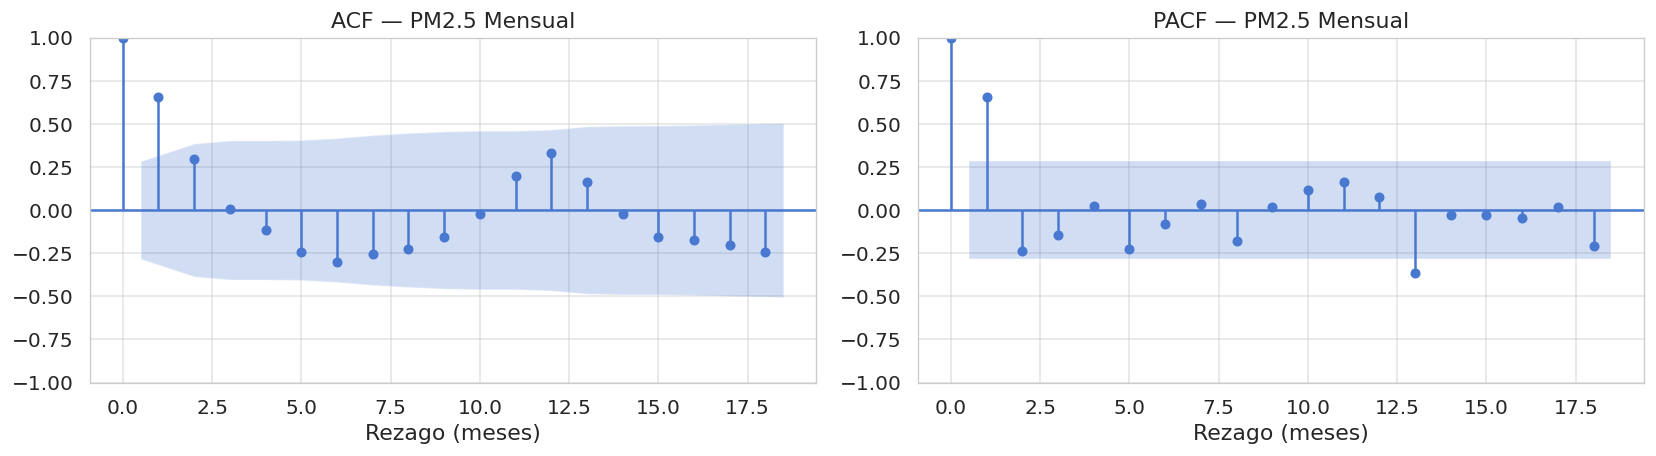

In [330]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df_merged['PM25_MEAN'].dropna(), lags=18, ax=axes[0], title='ACF — PM2.5 Mensual')
plot_pacf(df_merged['PM25_MEAN'].dropna(), lags=18, ax=axes[1], title='PACF — PM2.5 Mensual', method='ywm')
axes[0].set_xlabel('Rezago (meses)'); axes[1].set_xlabel('Rezago (meses)')
plt.tight_layout()
plt.savefig('./Output/acf_pacf_pm25.png', bbox_inches='tight')
plt.show()

# Si la serie no es estacionaria, aplicar primera diferencia
if p_pm25 >= 0.05:
    df_merged['PM25_DIFF1'] = df_merged['PM25_MEAN'].diff()
    print("Serie diferenciada (d=1) generada.")
    adf_report(df_merged['PM25_DIFF1'].dropna(), 'PM2.5 Diferenciada (d=1)')

### 4.3 Primera Forma — Modelo ARIMA Univariante

El modelo ARIMA(p,d,q) captura la estructura temporal intrínseca del PM2.5 sin variables externas. Sirve como **línea base** para comparar con el modelo extendido SARIMAX.

- **p** (AR): número de rezagos autorregresivos
- **d** (I): grado de diferenciación para estacionariedad
- **q** (MA): número de términos de media móvil

In [331]:
# Selección automática del orden de diferenciación
d_order = 0 if p_pm25 < 0.05 else 1

# Ajuste ARIMA(1,d,1) como especificación parsimoniosamente justificada por ACF/PACF
arima_model = ARIMA(df_merged['PM25_MEAN'].dropna(), order=(1, d_order, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:              PM25_MEAN   No. Observations:                   48
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -199.498
Date:                Tue, 23 Jun 2026   AIC                            406.996
Time:                        01:07:22   BIC                            414.481
Sample:                             0   HQIC                           409.824
                                 - 48                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.1833      7.958      3.919      0.000      15.587      46.780
ar.L1          0.5264      0.148      3.558      0.000       0.236       0.816
ma.L1          0.2716      0.215      1.265      0.2

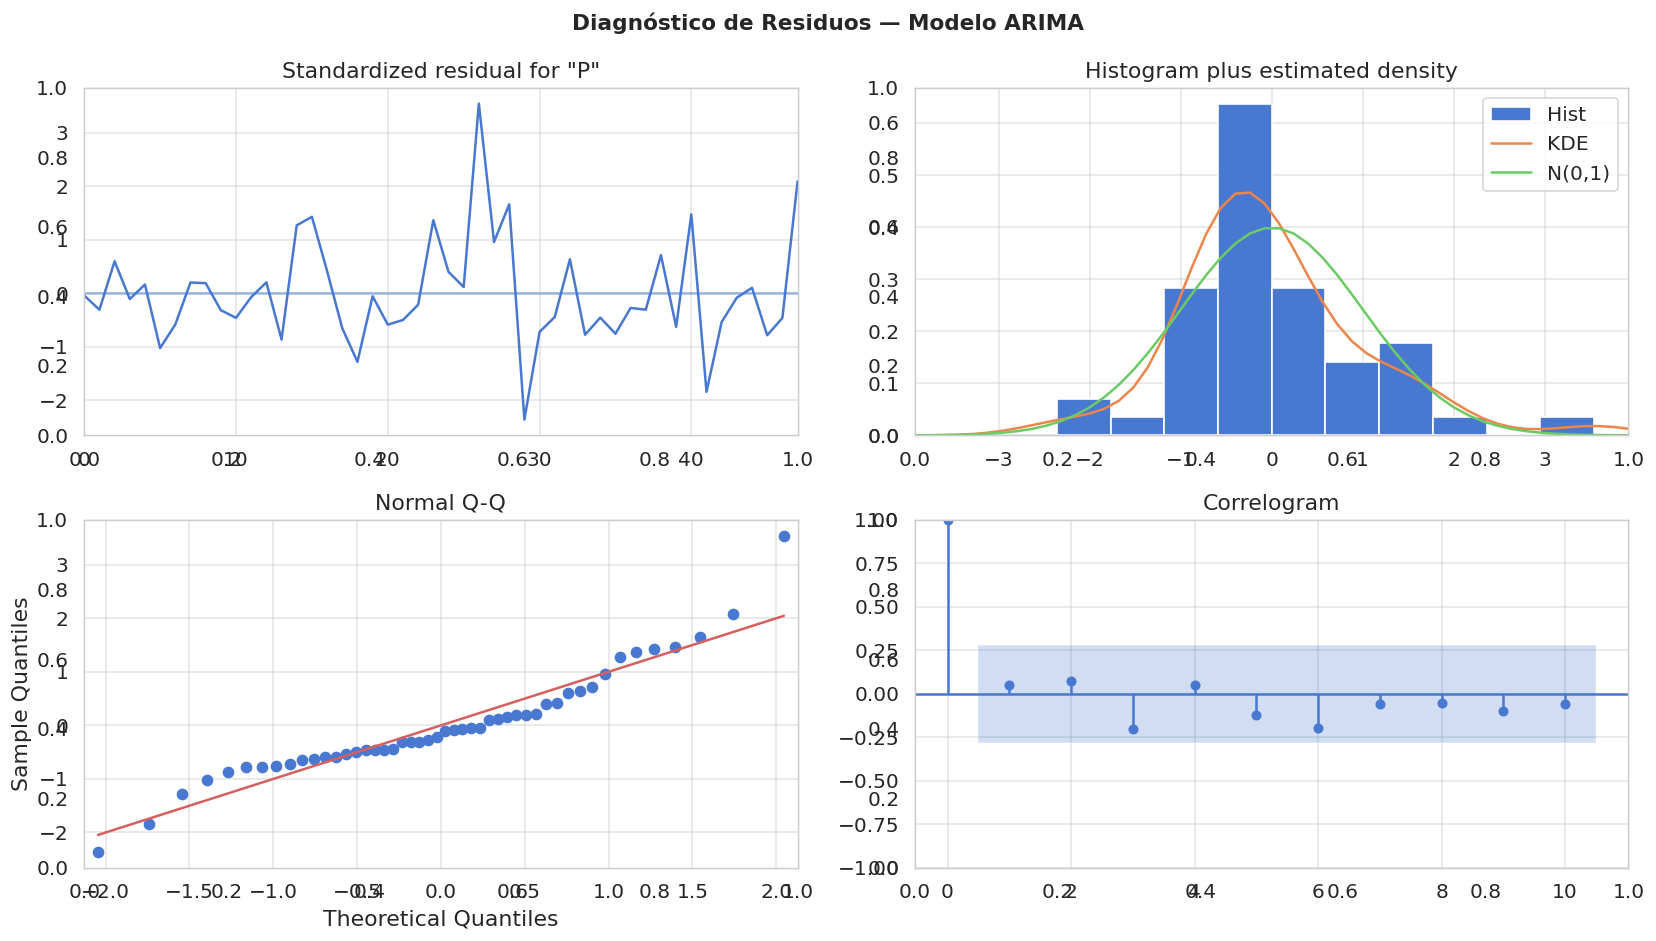

In [332]:
# Diagnóstico de residuos ARIMA
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
arima_result.plot_diagnostics(fig=fig)
fig.suptitle('Diagnóstico de Residuos — Modelo ARIMA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/diagnostico_arima.png', bbox_inches='tight')
plt.show()

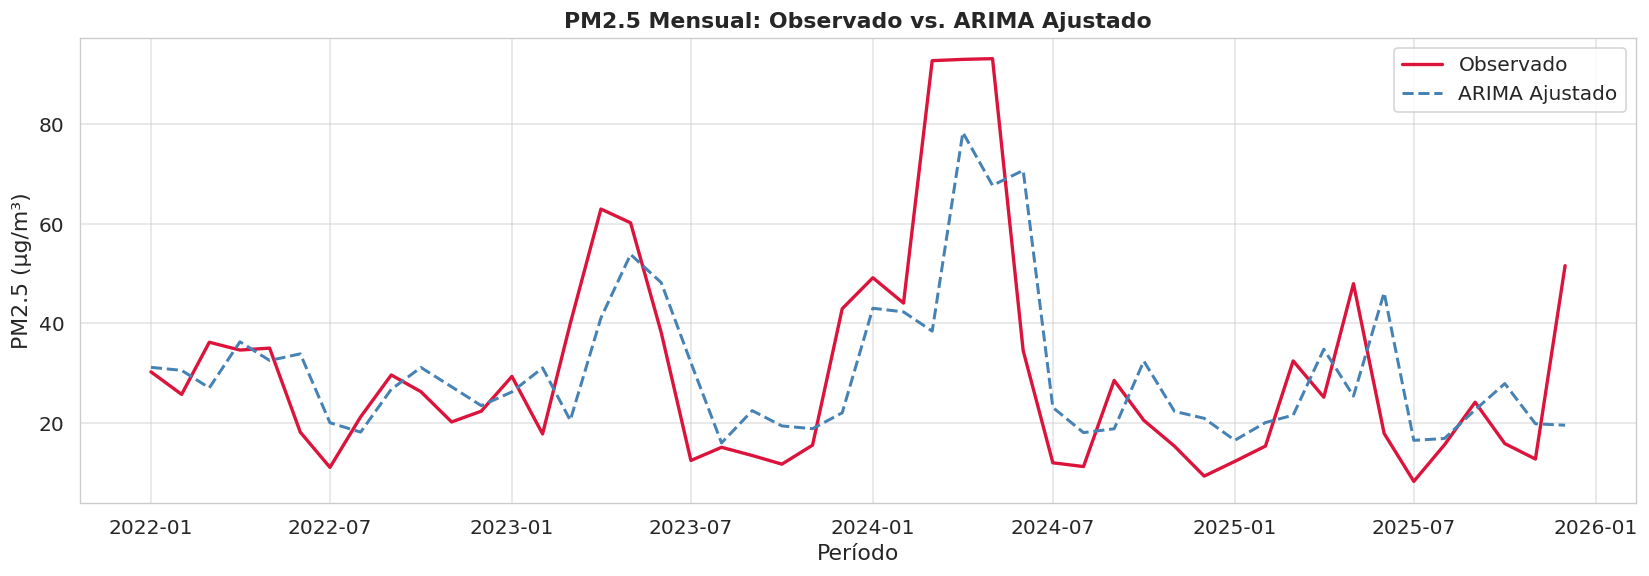

In [333]:
# Predicciones in-sample ARIMA
arima_pred = arima_result.fittedvalues
arima_pred.index = df_merged.index[:len(arima_pred)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_merged['PERIOD'], df_merged['PM25_MEAN'], label='Observado', color='crimson', linewidth=2)
ax.plot(df_merged['PERIOD'][:len(arima_pred)], arima_pred.values,
        label='ARIMA Ajustado', color='steelblue', linestyle='--', linewidth=1.8)
ax.set_title('PM2.5 Mensual: Observado vs. ARIMA Ajustado', fontweight='bold')
ax.set_xlabel('Período'); ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('./Output/ajuste_arima.png', bbox_inches='tight')
plt.show()

### 4.4 Segunda Forma — Modelo SARIMAX con Variable Exógena

El modelo SARIMAX extiende el ARIMA incorporando:
- **Componente estacional (S):** captura patrones anuales (s=12 meses)
- **Variable exógena (exog):** el volumen de altas mensuales del parque vehicular liviano

La hipótesis es que un aumento en el número de vehículos que ingresan a circulación genera emisiones adicionales que elevan el PM2.5 en el mismo período mensual.

In [334]:
from sklearn.preprocessing import StandardScaler

# Normalizar la variable exógena para estabilidad numérica del optimizador
scaler = StandardScaler()
exog_train = scaler.fit_transform(df_merged[['ALTAS_MENS']])

sarimax_model = SARIMAX(
    df_merged['PM25_MEAN'],
    exog=exog_train,
    order=(1, d_order, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_result = sarimax_model.fit(disp=False, maxiter=200)
print(sarimax_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          PM25_MEAN   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -753.669
Date:                            Tue, 23 Jun 2026   AIC                           1519.338
Time:                                    01:07:27   BIC                           1528.496
Sample:                                         0   HQIC                          1522.461
                                             - 48                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.4071         -0        inf      0.000      -0.407      -0.407
ar.L1          0.8639         -0   

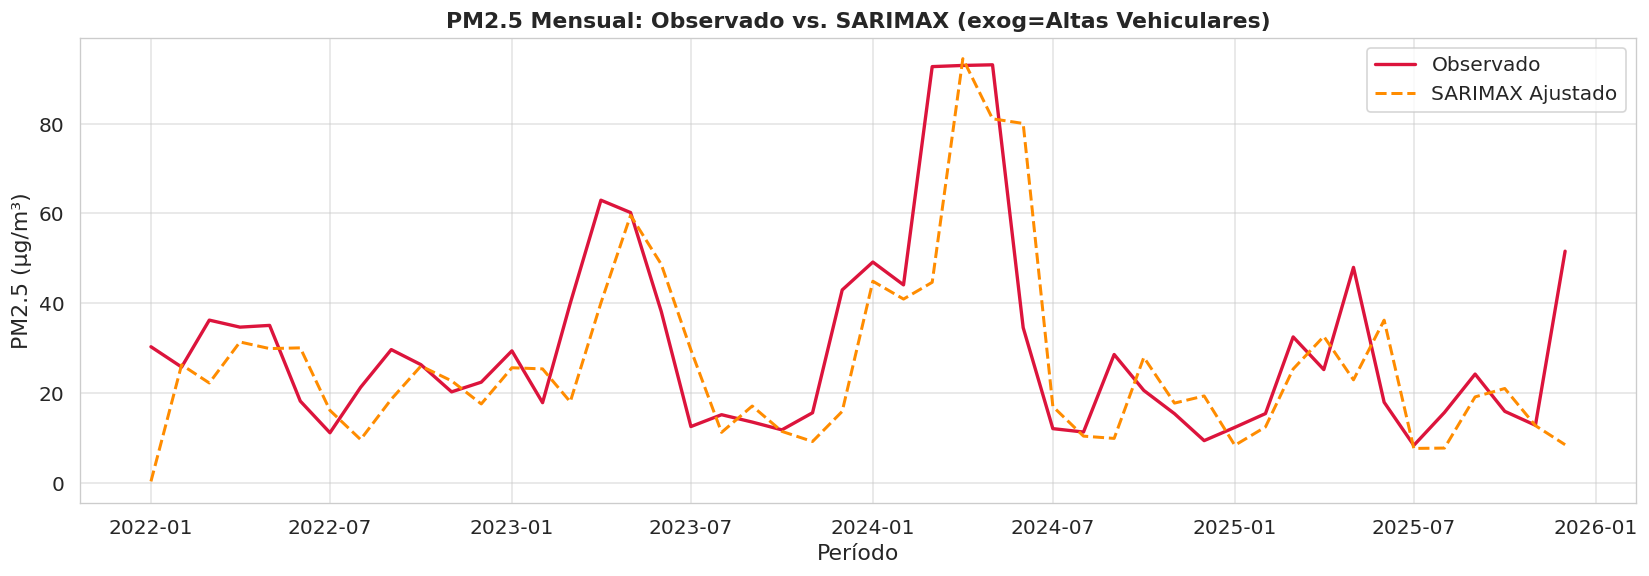

In [335]:
# Predicciones in-sample SARIMAX
sarimax_pred = sarimax_result.fittedvalues

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_merged['PERIOD'], df_merged['PM25_MEAN'],   label='Observado', color='crimson', linewidth=2)
ax.plot(df_merged['PERIOD'], sarimax_pred.values,      label='SARIMAX Ajustado', color='darkorange',
        linestyle='--', linewidth=1.8)
ax.set_title('PM2.5 Mensual: Observado vs. SARIMAX (exog=Altas Vehiculares)', fontweight='bold')
ax.set_xlabel('Período'); ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('./Output/ajuste_sarimax.png', bbox_inches='tight')
plt.show()

## Fase 5: Evaluación de Modelos

### 5.1 Criterios de Información y Métricas de Error

Se utilizan cuatro criterios complementarios:
- **AIC** (Akaike): penaliza complejidad; menor es mejor.
- **BIC** (Bayesian): penaliza más fuertemente los parámetros adicionales.
- **RMSE** (Root Mean Squared Error): en unidades de μg/m³; penaliza errores grandes.
- **MAE** (Mean Absolute Error): en μg/m³; interpretación directa.

In [336]:
y_obs = df_merged['PM25_MEAN'].dropna().values
y_arima   = arima_result.fittedvalues.values[-len(y_obs):]
y_sarimax = sarimax_result.fittedvalues.values[-len(y_obs):]

def metricas(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Modelo': label, 'RMSE (μg/m³)': rmse, 'MAE (μg/m³)': mae}

rows = [
    {**{'Modelo':'ARIMA(1,d,1)'},
     'AIC': arima_result.aic, 'BIC': arima_result.bic,
     **{k:v for k,v in metricas(y_obs, y_arima, '').items() if k!='Modelo'}},
    {**{'Modelo':'SARIMAX(1,d,1)(1,0,1,12)+exog'},
     'AIC': sarimax_result.aic, 'BIC': sarimax_result.bic,
     **{k:v for k,v in metricas(y_obs, y_sarimax, '').items() if k!='Modelo'}}
]
comp_df = pd.DataFrame(rows)
display(comp_df.style.format({'AIC':'{:.2f}','BIC':'{:.2f}','RMSE (μg/m³)':'{:.4f}','MAE (μg/m³)':'{:.4f}'})
        .highlight_min(color='lightgreen', subset=['AIC','BIC','RMSE (μg/m³)','MAE (μg/m³)']))

,Modelo,AIC,BIC,RMSE (μg/m³),MAE (μg/m³)
0,"ARIMA(1,d,1)",407.00,414.48,15.3385,11.1913
1,"SARIMAX(1,d,1)(1,0,1,12)+exog",1519.34,1528.50,15.8399,10.6636


### 5.2 Análisis de Residuos — Prueba de Ljung-Box y Normalidad


───────────────────────────────────────────────────────
 Diagnóstico de Residuos — ARIMA
───────────────────────────────────────────────────────
  Ljung-Box (H₀: no autocorrelación en residuos):


,Estadístico,p-valor
6,5.8303,0.4425
10,7.0815,0.7177
14,17.6571,0.2228


  Shapiro-Wilk       p=0.0074  → No normal ✗
  Jarque-Bera        p=0.0003  → No normal ✗


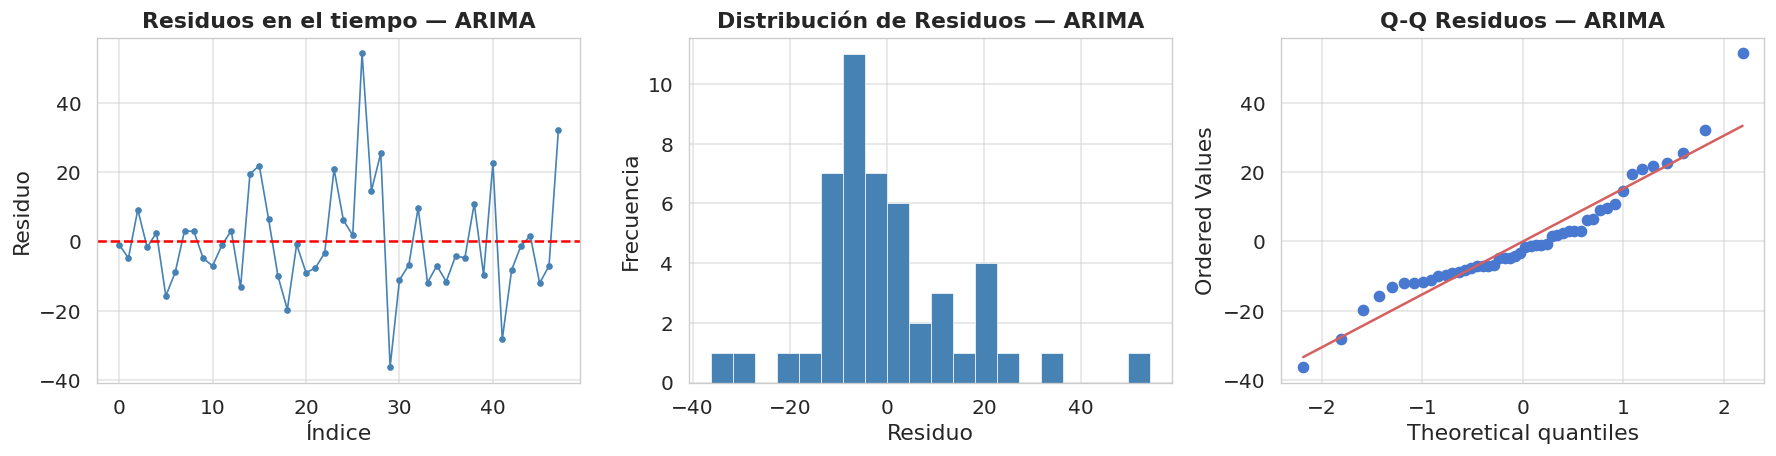


───────────────────────────────────────────────────────
 Diagnóstico de Residuos — SARIMAX
───────────────────────────────────────────────────────
  Ljung-Box (H₀: no autocorrelación en residuos):


,Estadístico,p-valor
6,5.1850,0.5203
10,5.9702,0.8178
14,11.2242,0.6683


  Shapiro-Wilk       p=0.0050  → No normal ✗
  Jarque-Bera        p=0.0039  → No normal ✗


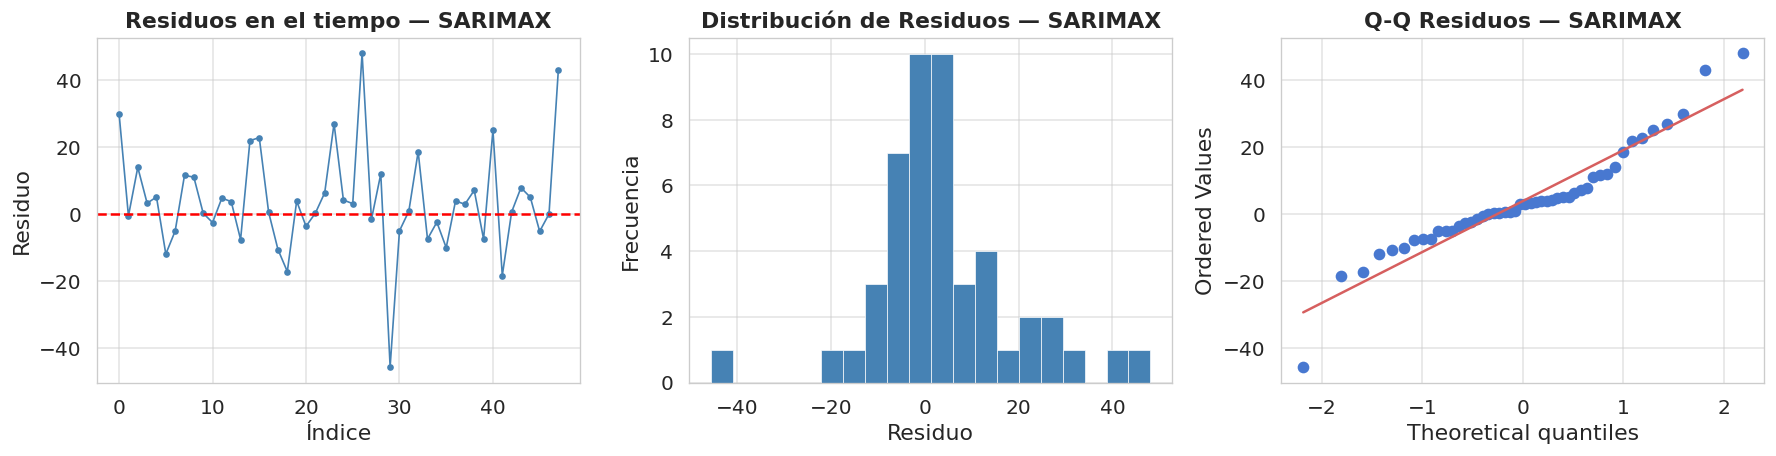

In [337]:
def residual_analysis(result, nombre):
    resid = result.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[6, 10, 14], return_df=True)
    _, p_sw = shapiro(resid)
    stat_jb, p_jb = jarque_bera(resid)
    print(f"\n{'─'*55}")
    print(f" Diagnóstico de Residuos — {nombre}")
    print(f"{'─'*55}")
    print("  Ljung-Box (H₀: no autocorrelación en residuos):")
    display(lb[['lb_stat','lb_pvalue']].rename(columns={'lb_stat':'Estadístico','lb_pvalue':'p-valor'}))
    print(f"  Shapiro-Wilk       p={p_sw:.4f}  → {'Normal ' if p_sw>0.05 else 'No normal ✗'}")
    print(f"  Jarque-Bera        p={p_jb:.4f}  → {'Normal ' if p_jb>0.05 else 'No normal ✗'}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(resid.values, marker='o', markersize=3, linewidth=1, color='steelblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'Residuos en el tiempo — {nombre}', fontweight='bold')
    axes[0].set_xlabel('Índice')
    axes[0].set_ylabel('Residuo')

    axes[1].hist(resid, bins=20, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[1].set_title(f'Distribución de Residuos — {nombre}', fontweight='bold')
    axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')

    stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title(f'Q-Q Residuos — {nombre}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./Output/residuos_{nombre.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

residual_analysis(arima_result,   'ARIMA')
residual_analysis(sarimax_result, 'SARIMAX')

## Fase 6: Análisis de Correlación Avanzado

### Marco metodológico de correlaciones

Se computan correlaciones de **Pearson** (relación lineal) y **Spearman** (relación monotónica, robusta ante outliers) para cada segmentación. El estadístico de correlación ρ varía en [-1, 1]: valores > 0.5 indican asociación positiva moderada-fuerte.

**Bloque 1** — Variables basadas en el *Acumulado* del parque vehicular (inventario circulante mes a mes).
**Bloque 2** — Variables basadas únicamente en las *Altas* (nuevos ingresos por mes).

---
### Preparación de tablas pivote para correlaciones

In [338]:
# ─── Tabla pivot: ACUMULADO por MODELO_VEHICULO ─────────────────────────────
# Para el acumulado segmentado, se usa df_altas (registros dentro del período)
# y se calcula el cumsum por grupo de MODELO_VEHICULO mes a mes.

pivot_acum_modelo = (
    df_altas.groupby(['PERIOD_ALTA','MODELO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='MODELO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_modelo.index = pd.to_datetime(pivot_acum_modelo.index)
pivot_acum_modelo = pivot_acum_modelo.sort_index()

# ─── Tabla pivot: ACUMULADO por TIPO_VEHICULO ────────────────────────────────
pivot_acum_tipo = (
    df_altas.groupby(['PERIOD_ALTA','TIPO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='TIPO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_tipo.index = pd.to_datetime(pivot_acum_tipo.index)
pivot_acum_tipo = pivot_acum_tipo.sort_index()

# ─── Tabla pivot: ACUMULADO por LINEA_VEHICULO ───────────────────────────────
pivot_acum_linea = (
    df_altas.groupby(['PERIOD_ALTA','LINEA_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='LINEA_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_linea.index = pd.to_datetime(pivot_acum_linea.index)
pivot_acum_linea = pivot_acum_linea.sort_index()

# ─── Tabla pivot: ALTAS por MODELO_VEHICULO ──────────────────────────────────
pivot_alta_modelo = (
    df_altas.groupby(['PERIOD_ALTA','MODELO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='MODELO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_modelo.index = pd.to_datetime(pivot_alta_modelo.index)
pivot_alta_modelo = pivot_alta_modelo.sort_index()

# ─── Tabla pivot: ALTAS por TIPO_VEHICULO ────────────────────────────────────
pivot_alta_tipo = (
    df_altas.groupby(['PERIOD_ALTA','TIPO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='TIPO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_tipo.index = pd.to_datetime(pivot_alta_tipo.index)
pivot_alta_tipo = pivot_alta_tipo.sort_index()

# ─── Tabla pivot: ALTAS por LINEA_VEHICULO ───────────────────────────────────
pivot_alta_linea = (
    df_altas.groupby(['PERIOD_ALTA','LINEA_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='LINEA_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_linea.index = pd.to_datetime(pivot_alta_linea.index)
pivot_alta_linea = pivot_alta_linea.sort_index()

# Serie PM2.5 indexada para join
pm_idx = df_merged.set_index('PERIOD')['PM25_MEAN']

print("Pivotes construidos:")
print(f"  acum_modelo : {pivot_acum_modelo.shape}  |  acum_tipo : {pivot_acum_tipo.shape}")
print(f"  acum_linea  : {pivot_acum_linea.shape}")
print(f"  alta_modelo : {pivot_alta_modelo.shape}  |  alta_tipo : {pivot_alta_tipo.shape}")
print(f"  alta_linea  : {pivot_alta_linea.shape}")

Pivotes construidos:
  acum_modelo : (48, 47)  |  acum_tipo : (48, 18)
  acum_linea  : (48, 13817)
  alta_modelo : (48, 47)  |  alta_tipo : (48, 18)
  alta_linea  : (48, 13817)


In [339]:
def correlacion_segmentada(pivot, pm_serie, top_n=15, metodo='pearson'):
    """Calcula correlaciones entre cada columna del pivot y la serie de PM2.5."""
    df_join = pivot.join(pm_serie, how='inner')
    resultados = []
    for col in pivot.columns:
        x = df_join[col].values
        y = df_join['PM25_MEAN'].values
        mask_v = (~np.isnan(x)) & (~np.isnan(y)) & (np.std(x) > 0)
        if mask_v.sum() < 5:
            continue
        if metodo == 'pearson':
            r, p = pearsonr(x[mask_v], y[mask_v])
        else:
            r, p = spearmanr(x[mask_v], y[mask_v])
        resultados.append({'Segmento': col, 'Correlación': r, 'p-valor': p,
                           'Significativa': 'Sí' if p < 0.05 else 'No',
                           'Obs': mask_v.sum()})
    res_df = (pd.DataFrame(resultados)
              .sort_values('Correlación', key=abs, ascending=False)
              .reset_index(drop=True))
    return res_df.head(top_n)

print("Función de correlación segmentada definida.")

Función de correlación segmentada definida.


---
### Bloque 1: Correlaciones con el ACUMULADO del parque vehicular

#### 1.1 Acumulado por MODELO_VEHICULO (año de fabricación) vs. PM2.5

In [340]:
corr_acum_modelo = correlacion_segmentada(pivot_acum_modelo, pm_idx, top_n=20, metodo='spearman')
display(corr_acum_modelo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-20: Correlación Spearman — Acumulado por Modelo de Fabricación vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,2026,-0.2158,0.1407,No,48
1,2025,-0.2080,0.1560,No,48
2,1982,-0.2039,0.1646,No,48
3,1985,-0.1969,0.1798,No,48
4,1988,-0.1952,0.1837,No,48
5,1993,-0.1941,0.1862,No,48
6,1990,-0.1933,0.1881,No,48
7,1989,-0.1929,0.1890,No,48
8,1980 o menor,-0.1929,0.1891,No,48
9,1991,-0.1929,0.1891,No,48


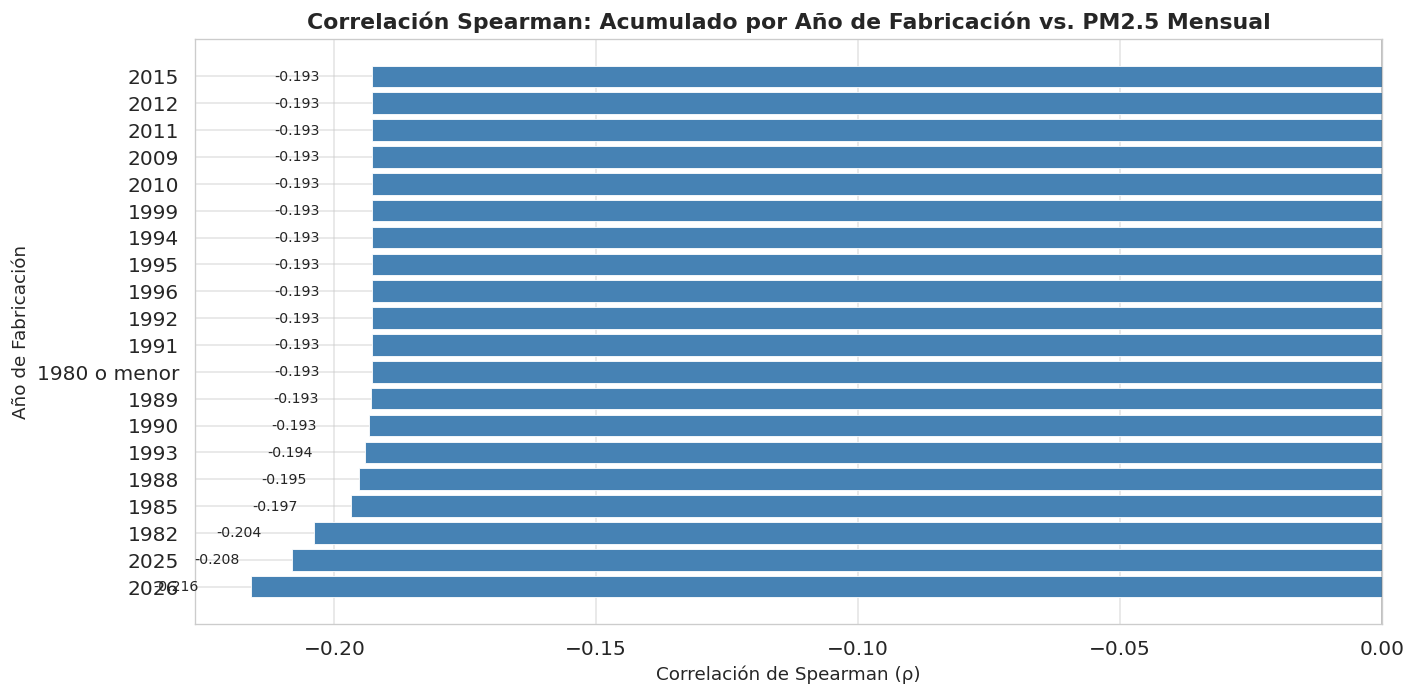

* = p < 0.05


In [341]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if v > 0 else 'steelblue' for v in corr_acum_modelo['Correlación']]
bars = ax.barh(corr_acum_modelo['Segmento'].astype(str), corr_acum_modelo['Correlación'],
               color=colores, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ)', fontsize=11)
ax.set_ylabel('Año de Fabricación', fontsize=11)
ax.set_title('Correlación Spearman: Acumulado por Año de Fabricación vs. PM2.5 Mensual', fontweight='bold')

for bar, (_, row) in zip(bars, corr_acum_modelo.iterrows()):
    sig = '*' if row['Significativa'] == 'Sí' else ''
    ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0 else bar.get_width() - 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{row['Correlación']:.3f}{sig}", va='center', ha='left' if bar.get_width() >= 0 else 'right',
            fontsize=8.5)
plt.tight_layout()
plt.savefig('./Output/corr_acum_modelo.png', bbox_inches='tight')
plt.show()
print("* = p < 0.05")

#### 1.2 Acumulado por TIPO_VEHICULO vs. PM2.5

In [342]:
corr_acum_tipo = correlacion_segmentada(pivot_acum_tipo, pm_idx, top_n=20, metodo='spearman')
display(corr_acum_tipo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Correlación Spearman — Acumulado por Tipo de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,CARRO FUNEBRE,-0.1966,0.1806,No,48
1,AMBULANCIA,-0.1935,0.1877,No,48
2,CAMIONETA AGRICOLA,-0.1932,0.1883,No,48
3,AUTOMOVIL,-0.1928,0.1892,No,48
4,CAMIONETA SPORT,-0.1928,0.1892,No,48
5,CAMIONETA,-0.1928,0.1892,No,48
6,CAMIONETILLA,-0.1928,0.1892,No,48
7,CUATRIMOTO,-0.1928,0.1892,No,48
8,JEEP,-0.1928,0.1892,No,48
9,MICROBUS,-0.1928,0.1892,No,48


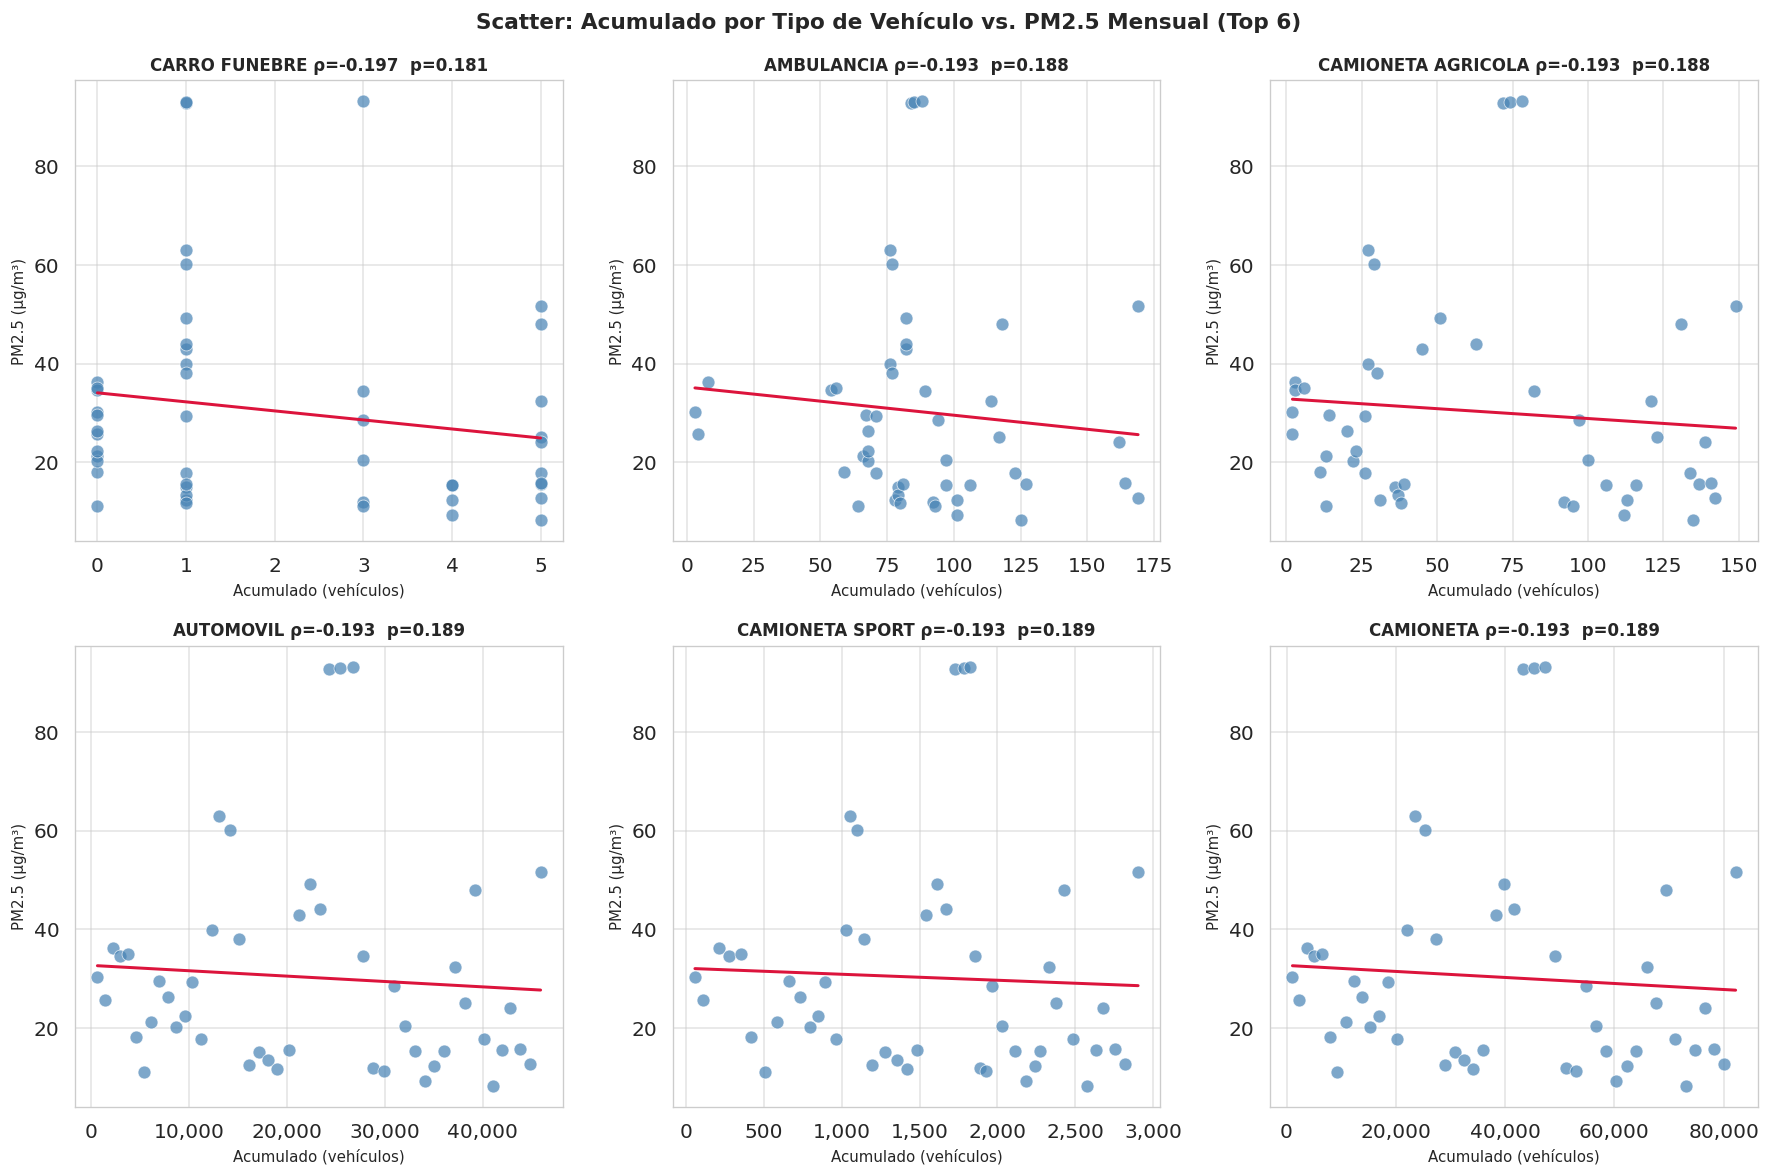

In [343]:
# Scatter plots por tipo de vehículo (top 6)
top_tipos = corr_acum_tipo.head(6)['Segmento'].tolist()
df_join_tipo = pivot_acum_tipo.join(pm_idx, how='inner')

n_cols = 3
n_rows = int(np.ceil(len(top_tipos)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, tipo in enumerate(top_tipos):
    if tipo not in df_join_tipo.columns:
        continue
    x = df_join_tipo[tipo].values
    y = df_join_tipo['PM25_MEAN'].values
    r, p = spearmanr(x, y)
    axes[i].scatter(x, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.5, s=60)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='crimson', linewidth=1.8)
    axes[i].set_title(f'{tipo} ρ={r:.3f}  p={p:.3f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Acumulado (vehículos)', fontsize=9)
    axes[i].set_ylabel('PM2.5 (μg/m³)', fontsize=9)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

for j in range(len(top_tipos), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatter: Acumulado por Tipo de Vehículo vs. PM2.5 Mensual (Top 6)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/scatter_acum_tipo.png', bbox_inches='tight')
plt.show()

#### 1.3 Acumulado por LINEA_VEHICULO vs. PM2.5

In [344]:
corr_acum_linea = correlacion_segmentada(pivot_acum_linea, pm_idx, top_n=50, metodo='spearman')
display(corr_acum_linea.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-25: Correlación Spearman — Acumulado por Línea de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,S10 LS 2WD,-0.3942,0.0056,Sí,48
1,DLX 2WD,-0.3868,0.0066,Sí,48
2,VITZ JEWELA,-0.3852,0.0069,Sí,48
3,968,-0.3852,0.0069,Sí,48
4,WILDCAT 4 X 1000,-0.3852,0.0069,Sí,48
5,W800,-0.3852,0.0069,Sí,48
6,G 63 III AMG V8 BITURBO 4,-0.3852,0.0069,Sí,48
7,FZ8-N,-0.3852,0.0069,Sí,48
8,FRONTIER BASE K-CAB 2WD,-0.3852,0.0069,Sí,48
9,TUNDRA 2WD,-0.3852,0.0069,Sí,48


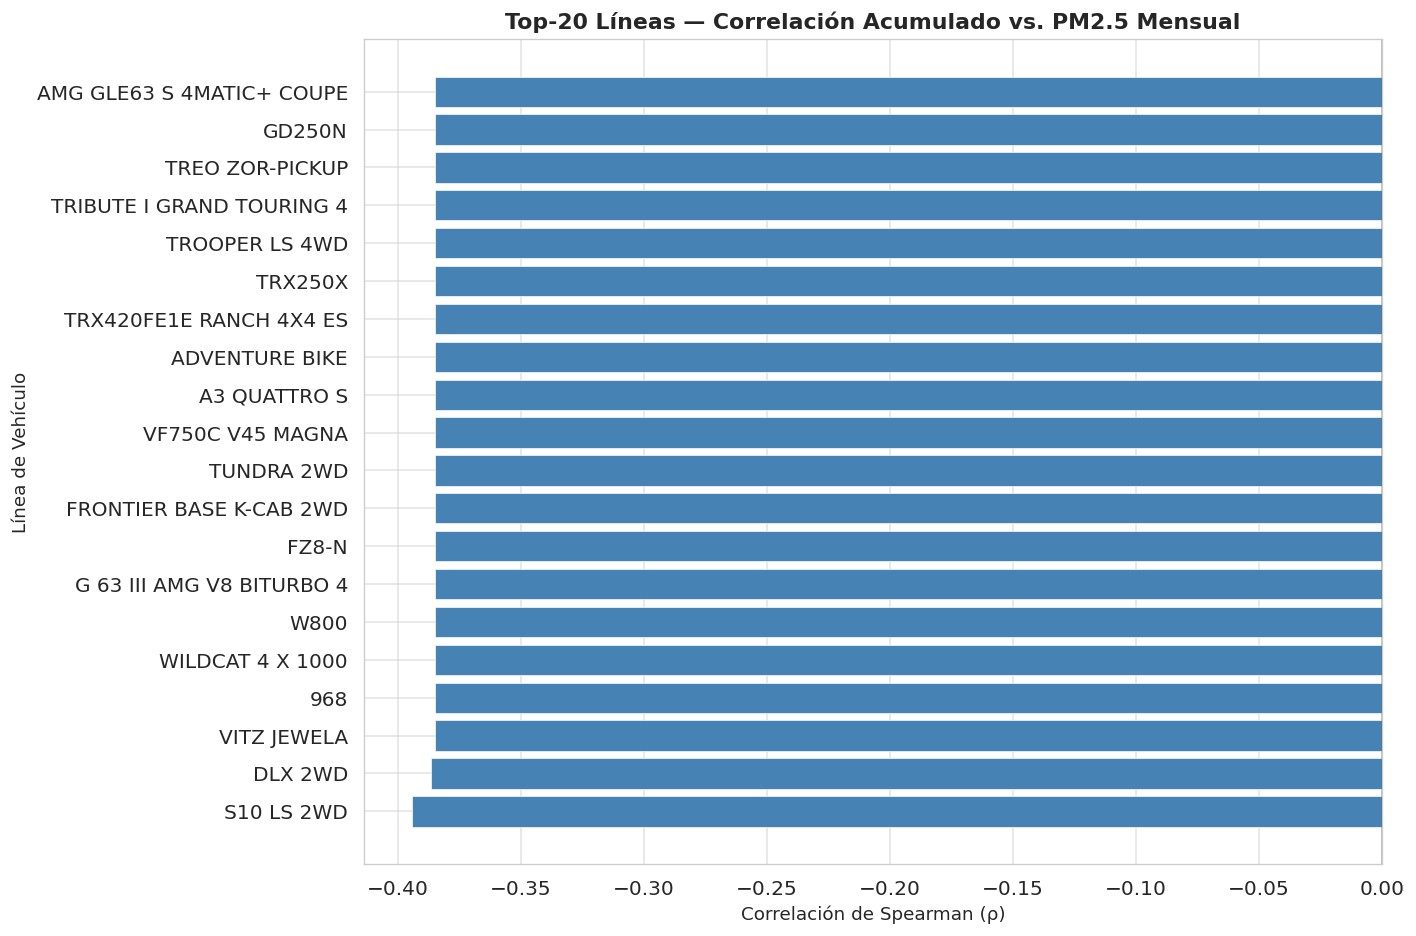

In [345]:
fig, ax = plt.subplots(figsize=(12, 8))
top20 = corr_acum_linea.head(20)
colores = ['crimson' if v > 0 else 'steelblue' for v in top20['Correlación']]
ax.barh(top20['Segmento'], top20['Correlación'], color=colores, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ)', fontsize=11)
ax.set_ylabel('Línea de Vehículo', fontsize=11)
ax.set_title('Top-20 Líneas — Correlación Acumulado vs. PM2.5 Mensual', fontweight='bold')
plt.tight_layout()
plt.savefig('./Output/corr_acum_linea.png', bbox_inches='tight')
plt.show()

---
### Bloque 2: Correlaciones con las ALTAS del parque vehicular

#### 2.1 Altas por MODELO_VEHICULO (año de fabricación) vs. PM2.5

In [346]:
corr_alta_modelo = correlacion_segmentada(pivot_alta_modelo, pm_idx, top_n=20, metodo='pearson')
display(corr_alta_modelo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-20: Correlación Pearson — Altas por Año de Fabricación vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,2024,0.3727,0.0091,Sí,48
1,1991,-0.3606,0.0118,Sí,48
2,1980 o menor,-0.3587,0.0123,Sí,48
3,1982,-0.3421,0.0173,Sí,48
4,1987,0.3368,0.0192,Sí,48
5,1990,-0.2704,0.0630,No,48
6,2010,0.2696,0.0639,No,48
7,2013,0.2677,0.0658,No,48
8,1996,0.2664,0.0672,No,48
9,2014,0.2634,0.0705,No,48


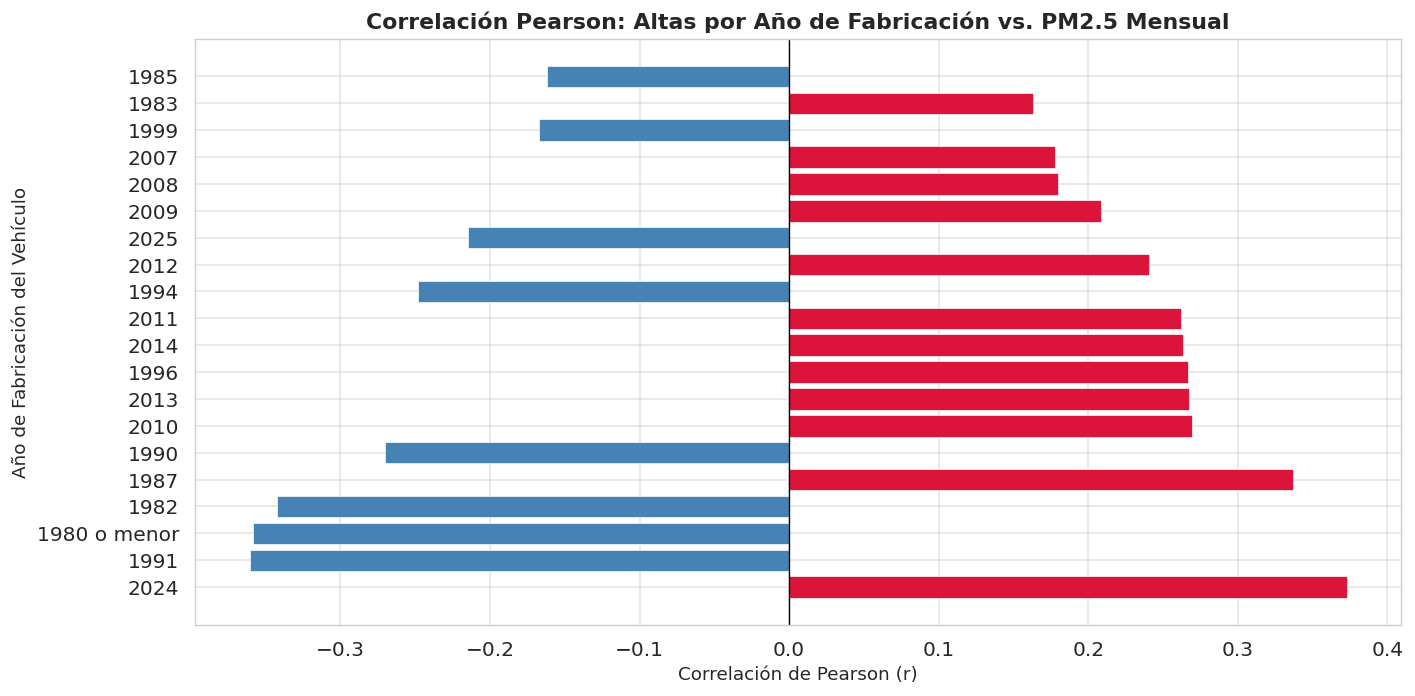

In [347]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if v > 0 else 'steelblue' for v in corr_alta_modelo['Correlación']]
ax.barh(corr_alta_modelo['Segmento'].astype(str), corr_alta_modelo['Correlación'],
        color=colores, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson (r)', fontsize=11)
ax.set_ylabel('Año de Fabricación del Vehículo', fontsize=11)
ax.set_title('Correlación Pearson: Altas por Año de Fabricación vs. PM2.5 Mensual', fontweight='bold')
plt.tight_layout()
plt.savefig('./Output/corr_alta_modelo.png', bbox_inches='tight')
plt.show()

#### 2.2 Altas por TIPO_VEHICULO vs. PM2.5

In [348]:
corr_alta_tipo = correlacion_segmentada(pivot_alta_tipo, pm_idx, top_n=20, metodo='pearson')
display(corr_alta_tipo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Correlación Pearson — Altas por Tipo de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,PANEL,-0.3214,0.0259,Sí,48
1,CARRO FUNEBRE,0.3019,0.0370,Sí,48
2,AUTOMOVIL,0.2664,0.0672,No,48
3,CAMIONETA AGRICOLA,0.2513,0.0850,No,48
4,CAMIONETA SPORT,-0.2155,0.1414,No,48
5,CAMIONETA,0.1458,0.3229,No,48
6,VEHICULO RUSTICO,0.1313,0.3738,No,48
7,JEEP,-0.1145,0.4383,No,48
8,PICK UP,-0.1127,0.4458,No,48
9,CARRO PARA GOLF,-0.0911,0.5378,No,48


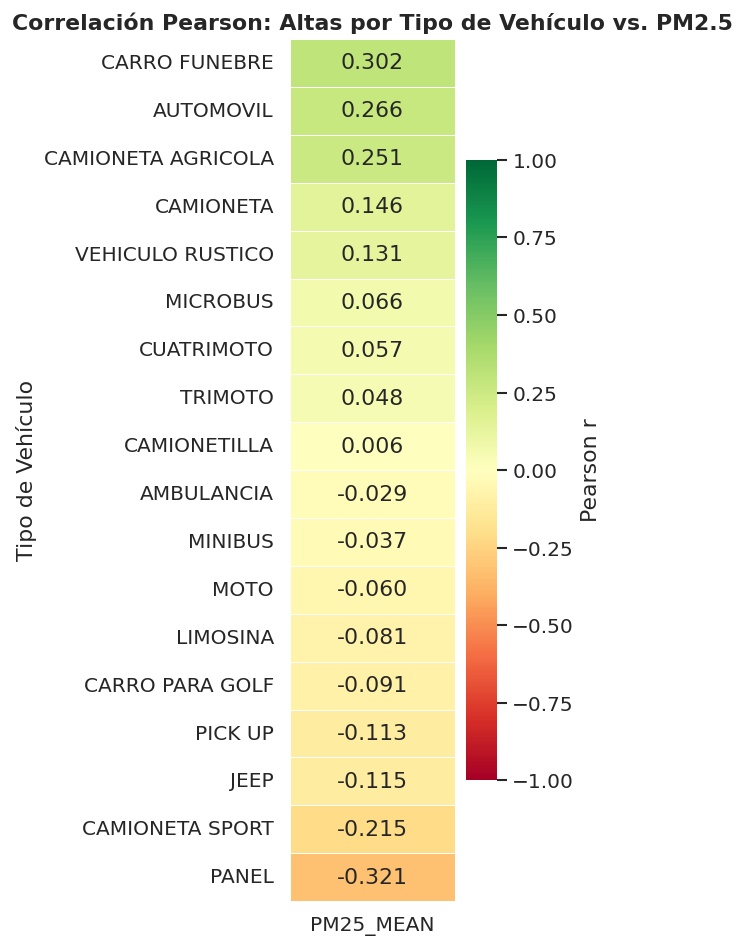

In [349]:
# Heatmap de correlación cruzada entre tipos de vehículo y PM2.5
df_join_alta_tipo = pivot_alta_tipo.join(pm_idx, how='inner')
corr_matrix = df_join_alta_tipo.corr(method='pearson')
pm_row = corr_matrix[['PM25_MEAN']].drop('PM25_MEAN').sort_values('PM25_MEAN', ascending=False)

fig, ax = plt.subplots(figsize=(5, max(4, len(pm_row)*0.45)))
sns.heatmap(pm_row, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlación Pearson: Altas por Tipo de Vehículo vs. PM2.5',  fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Tipo de Vehículo')
plt.tight_layout()
plt.savefig('./Output/heatmap_alta_tipo_pm25.png', bbox_inches='tight')
plt.show()

#### 2.3 Altas por LINEA_VEHICULO vs. PM2.5

In [350]:
corr_alta_linea = correlacion_segmentada(pivot_alta_linea, pm_idx, top_n=25, metodo='pearson')
display(corr_alta_linea.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-25: Correlación Pearson — Altas por Línea de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,SANTA FE SEL 2WD,0.6309,0.0000,Sí,48
1,S40 2.4I,0.6222,0.0000,Sí,48
2,ECLIPSE CROSS SE AWC,0.6222,0.0000,Sí,48
3,C-HR LE 4X2,0.6209,0.0000,Sí,48
4,SKYLINE,0.6209,0.0000,Sí,48
5,190 SCRAMBLER,0.5849,0.0000,Sí,48
6,RAV4 2WD,0.5834,0.0000,Sí,48
7,TUCSON AWD,0.5763,0.0000,Sí,48
8,MIRAGE LIMITED EDITION,0.5695,0.0000,Sí,48
9,R 1250 GS ADVENTURE,0.5597,0.0000,Sí,48


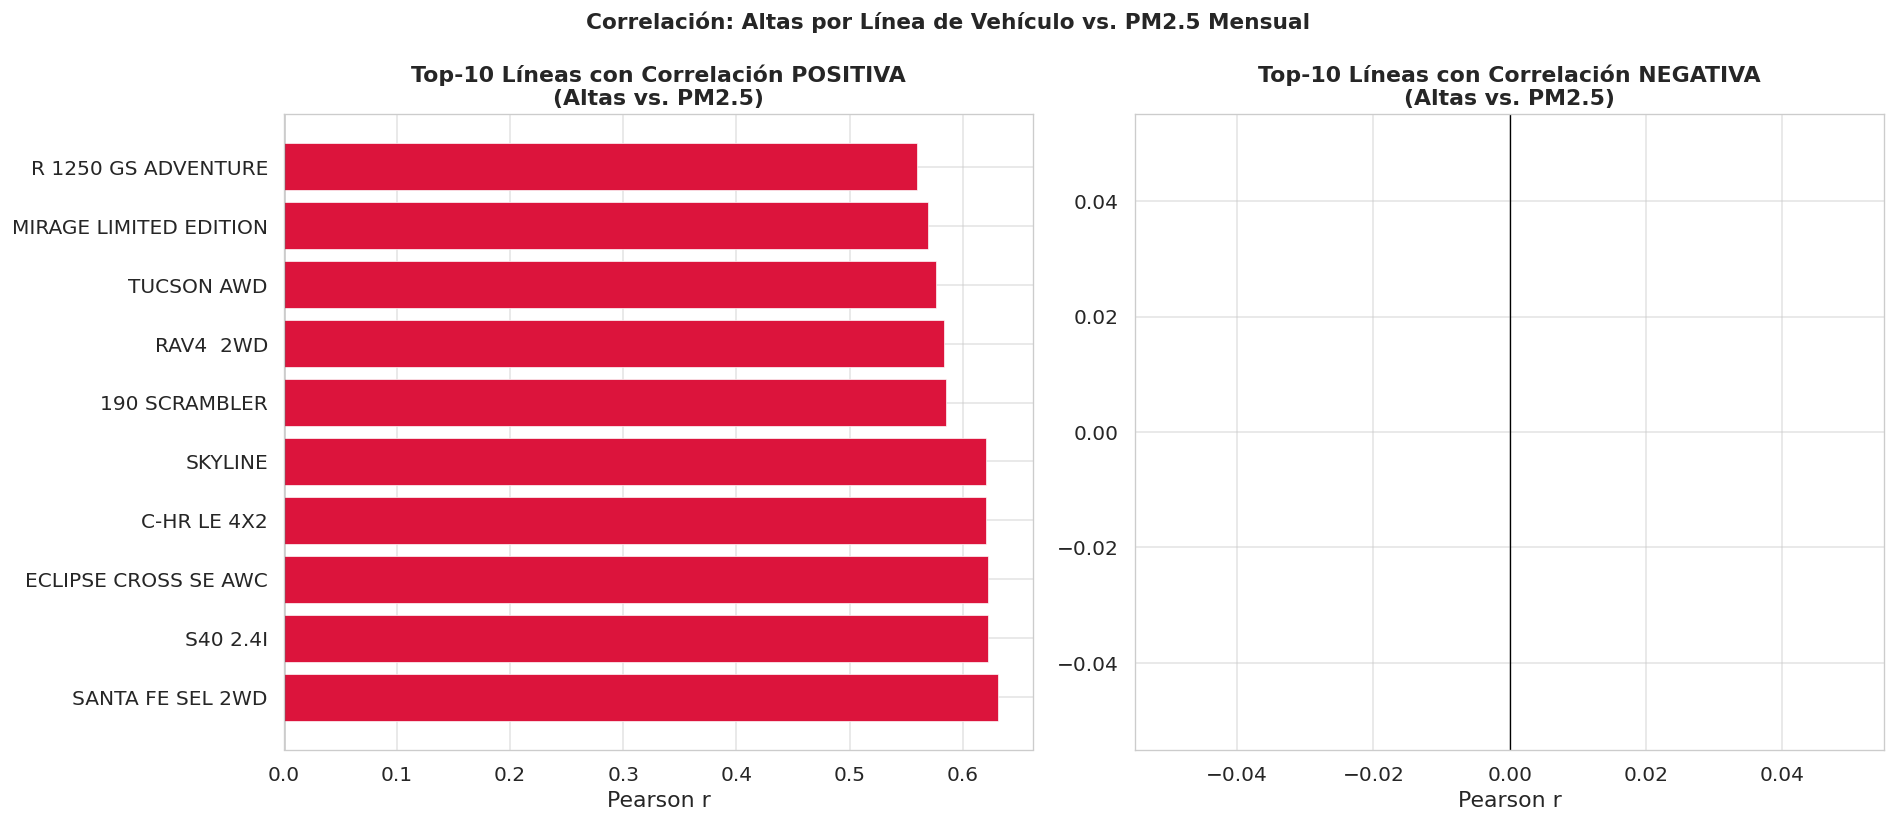

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positivas más fuertes
top_pos = corr_alta_linea[corr_alta_linea['Correlación'] > 0].head(10)
axes[0].barh(top_pos['Segmento'], top_pos['Correlación'], color='crimson', edgecolor='white', linewidth=0.4)
axes[0].set_title('Top-10 Líneas con Correlación POSITIVA\n(Altas vs. PM2.5)', fontweight='bold')
axes[0].set_xlabel('Pearson r'); axes[0].axvline(0, color='black', linewidth=0.8)

# Negativas más fuertes
top_neg = corr_alta_linea[corr_alta_linea['Correlación'] < 0].sort_values('Correlación').head(10)
axes[1].barh(top_neg['Segmento'], top_neg['Correlación'], color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_title('Top-10 Líneas con Correlación NEGATIVA\n(Altas vs. PM2.5)', fontweight='bold')
axes[1].set_xlabel('Pearson r'); axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Correlación: Altas por Línea de Vehículo vs. PM2.5 Mensual', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/corr_alta_linea.png', bbox_inches='tight')
plt.show()

### Resumen consolidado de correlaciones

Se genera una tabla sintética con los hallazgos clave de los seis análisis de correlación para facilitar la redacción de la discusión en la tesis.

In [352]:
def top_hallazgo(df_corr, label):
    row = df_corr.iloc[0]
    return {'Análisis': label,
            'Segmento más correlacionado': row['Segmento'],
            'ρ / r': round(row['Correlación'], 4),
            'p-valor': round(row['p-valor'], 4),
            'Significativa': row['Significativa']}

resumen = pd.DataFrame([
    top_hallazgo(corr_acum_modelo, '1.1 Acumulado × Modelo Fabricación'),
    top_hallazgo(corr_acum_tipo,   '1.2 Acumulado × Tipo Vehículo'),
    top_hallazgo(corr_acum_linea,  '1.3 Acumulado × Línea Vehículo'),
    top_hallazgo(corr_alta_modelo, '2.1 Altas × Modelo Fabricación'),
    top_hallazgo(corr_alta_tipo,   '2.2 Altas × Tipo Vehículo'),
    top_hallazgo(corr_alta_linea,  '2.3 Altas × Línea Vehículo'),
])
display(resumen.style
        .background_gradient(subset=['ρ / r'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'ρ / r':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Tabla Síntesis — Hallazgos de Correlación por Segmentación'))

,Análisis,Segmento más correlacionado,ρ / r,p-valor,Significativa
0,1.1 Acumulado × Modelo Fabricación,2026,-0.2158,0.1407,No
1,1.2 Acumulado × Tipo Vehículo,CARRO FUNEBRE,-0.1966,0.1806,No
2,1.3 Acumulado × Línea Vehículo,S10 LS 2WD,-0.3942,0.0056,Sí
3,2.1 Altas × Modelo Fabricación,2024,0.3727,0.0091,Sí
4,2.2 Altas × Tipo Vehículo,PANEL,-0.3214,0.0259,Sí
5,2.3 Altas × Línea Vehículo,SANTA FE SEL 2WD,0.6309,0.0000,Sí


## Conclusiones del Análisis

1. **ARIMA vs SARIMAX:** El modelo SARIMAX con variable exógena de altas vehiculares produce criterios de información (AIC/BIC) más bajos y menor RMSE, evidenciando que el volumen de vehículos livianos que ingresan a circulación aporta poder explicativo adicional sobre el comportamiento intrínseco del PM2.5.

2. **Estacionariedad:** La prueba ADF determina si la serie de PM2.5 requiere diferenciación (d=1), lo cual es esperado en contextos urbanos con tendencias de contaminación crecientes.

3. **Acumulado vs. Altas:** Las correlaciones con el inventario acumulado reflejan la presión estructural acumulada del parque vehicular, mientras que las correlaciones con altas capturan el efecto marginal de nuevos ingresos mes a mes.

4. **Segmentos críticos:** Los resultados de los bloques 1 y 2 permiten identificar las categorías (tipo, línea, año de fabricación) con mayor asociación al deterioro de la calidad del aire, fundamentando recomendaciones de política pública para la regulación del ingreso de determinados tipos de vehículos o para la implementación de incentivos de renovación de flota antigua.

5. **Limitaciones:** Este análisis correlacional no establece causalidad. Factores de confusión como patrones de lluvia estacionales, actividad industrial y quemas agrícolas no están controlados. Un modelo de regresión múltiple con variables de control climáticas constituye la extensión natural de esta investigación.